In [34]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import RegexpTokenizer
from collections import defaultdict
import ir_datasets
from itertools import islice
import matplotlib.pyplot as plt

dataset = ir_datasets.load("cranfield")

In [35]:
# Cài đặt thư viện sklearn nếu chưa có
try:
    import sklearn
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])
    import sklearn


In [36]:
for doc in islice(dataset.docs_iter(), 2):
    print(doc)

CranfieldDoc(doc_id='1', title='experimental investigation of the aerodynamics of a\nwing in a slipstream .', text='experimental investigation of the aerodynamics of a\nwing in a slipstream .\n  an experimental study of a wing in a propeller slipstream was\nmade in order to determine the spanwise distribution of the lift\nincrease due to slipstream at different angles of attack of the wing\nand at different free stream to slipstream velocity ratios .  the\nresults were intended in part as an evaluation basis for different\ntheoretical treatments of this problem .\n  the comparative span loading curves, together with\nsupporting evidence, showed that a substantial part of the lift increment\nproduced by the slipstream was due to a /destalling/ or\nboundary-layer-control effect .  the integrated remaining lift\nincrement, after subtracting this destalling lift, was found to agree\nwell with a potential flow theory .\n  an empirical evaluation of the destalling effects was made for\nthe s

In [37]:
for query in islice(dataset.queries_iter(), 2):
    print(query)

GenericQuery(query_id='1', text='what similarity laws must be obeyed when constructing aeroelastic models\nof heated high speed aircraft .')
GenericQuery(query_id='2', text='what are the structural and aeroelastic problems associated with flight\nof high speed aircraft .')


In [38]:
for qrel in islice(dataset.qrels_iter(), 2):
    print(qrel.query_id, qrel.doc_id, qrel.relevance)

1 184 2
1 29 2


In [39]:
# Định nghĩa các hàm tiền xử lý cho Vector Space Model
# VSM cần string input cho TfidfVectorizer
def preprocess_text_vsm(text, method='basic'):
    """
    Tiền xử lý văn bản theo các phương pháp khác nhau cho VSM
    Returns: string (for TfidfVectorizer)
    """
    # Chuyển về chữ thường
    text = text.lower()
    
    if method == 'basic':
        # Chỉ tokenization cơ bản
        tokens = word_tokenize(text)
        return ' '.join([token for token in tokens if token.isalpha()])
    
    elif method == 'stopwords':
        # Tokenization + loại bỏ stop words
        tokens = word_tokenize(text)
        stop_words = set(stopwords.words('english'))
        filtered_tokens = [token for token in tokens if token not in stop_words and token.isalpha()]
        return ' '.join(filtered_tokens)
    
    elif method == 'stemming':
        # Tokenization + stop words + stemming
        tokens = word_tokenize(text)
        stop_words = set(stopwords.words('english'))
        stemmer = PorterStemmer()
        filtered_tokens = [token for token in tokens if token not in stop_words and token.isalpha()]
        stemmed_tokens = [stemmer.stem(token) for token in filtered_tokens]
        return ' '.join(stemmed_tokens)
    
    elif method == 'lemmatization':
        # Tokenization + stop words + lemmatization
        tokens = word_tokenize(text)
        stop_words = set(stopwords.words('english'))
        lemmatizer = WordNetLemmatizer()
        filtered_tokens = [token for token in tokens if token not in stop_words and token.isalpha()]
        lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]
        return ' '.join(lemmatized_tokens)

# Giữ lại hàm cũ cho demo (trả về string)
def preprocess_text(text, method='basic'):
    """
    Tiền xử lý văn bản theo các phương pháp khác nhau (cho demo)
    Returns: string
    """
    return preprocess_text_vsm(text, method)

In [40]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

try:
    nltk.data.find('taggers/averaged_perceptron_tagger') 
except LookupError:
    nltk.download('averaged_perceptron_tagger')

# Tìm document ngắn nhất nhưng có ít nhất 10 từ để demo
print("Đang tìm document ngắn nhất có nội dung để demo...")
min_word_count = float('inf')
shortest_doc = None

for doc in dataset.docs_iter():
    # Tạo full text từ title + text
    full_text = (doc.title + " " + doc.text).strip()
    
    # Đếm số từ
    words = word_tokenize(full_text.lower())
    word_count = len([word for word in words if word.isalpha()])
    
    # Chỉ xét documents có ít nhất 10 từ
    if word_count >= 1 and word_count < min_word_count:
        min_word_count = word_count
        shortest_doc = doc

if shortest_doc:
    print(f"\nDocument ngắn nhất (có ít nhất 10 từ) được tìm thấy:")
    print(f"ID: {shortest_doc.doc_id}")
    print(f"Số từ: {min_word_count} từ")
    print(f"Độ dài: {len(shortest_doc.title) + len(shortest_doc.text)} ký tự")
    print(f"Title: {shortest_doc.title}")
    print(f"Text: {shortest_doc.text}")
    
    # Sử dụng document ngắn nhất để demo
    sample_doc = shortest_doc
else:
    print("Không tìm thấy document phù hợp, sử dụng document đầu tiên")
    for doc in dataset.docs_iter():
        sample_doc = doc
        break


Đang tìm document ngắn nhất có nội dung để demo...


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hello\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!



Document ngắn nhất (có ít nhất 10 từ) được tìm thấy:
ID: 1045
Số từ: 29 từ
Độ dài: 221 ký tự
Title: the bending strength of pressurized cylinders .
Text: the bending strength of pressurized cylinders .
  discussion of previously presented experimental data for the
loading of pressurized cylinders, in terms of membrane theory .


In [41]:
# Demo các kỹ thuật tiền xử lý văn bản
text = sample_doc.title + " " + sample_doc.text

print("=== DEMO CÁC KỸ THUẬT TIỀN XỬ LÝ VĂN BẢN ===\n")

# 1. Tokenization
print("1. TOKENIZATION")
print("Original:", text[:200] + "...")
tokens = word_tokenize(text.lower())
print("Tokens:", tokens[:20])
print(f"Số tokens: {len(tokens)}\n")

# 2. Loại bỏ Stop words
print("2. LOẠI BỎ STOP WORDS")
stop_words = set(stopwords.words('english'))
filtered_tokens = [token for token in tokens if token not in stop_words and token.isalpha()]
print("Stopword Removal:\n", filtered_tokens[:20])
print(f"Số tokens sau khi loại bỏ stop words: {len(filtered_tokens)}\n")

# 3. Stemming
print("3. STEMMING")
stemmer = PorterStemmer()
stemmed_tokens = [stemmer.stem(token) for token in filtered_tokens]
print("Stemming:\n", stemmed_tokens[:20])
print(f"Ví dụ stemming: {list(zip(filtered_tokens[:10], stemmed_tokens[:10]))}\n")

# 4. Lemmatization
print("4. LEMMATIZATION")
lemmatizer = WordNetLemmatizer()
lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]
print("Lemmatization:\n", lemmatized_tokens[:20])
print(f"Ví dụ lemmatization: {list(zip(filtered_tokens[:10], lemmatized_tokens[:10]))}")

# So sánh kết quả
print(f"\nTóm tắt:")
print(f"- Tokens gốc: {len(tokens)}")
print(f"- Sau loại bỏ stop words: {len(filtered_tokens)}")
print(f"- Tokens unique sau stemming: {len(set(stemmed_tokens))}")
print(f"- Tokens unique sau lemmatization: {len(set(lemmatized_tokens))}")


=== DEMO CÁC KỸ THUẬT TIỀN XỬ LÝ VĂN BẢN ===

1. TOKENIZATION
Original: the bending strength of pressurized cylinders . the bending strength of pressurized cylinders .
  discussion of previously presented experimental data for the
loading of pressurized cylinders, in term...
Tokens: ['the', 'bending', 'strength', 'of', 'pressurized', 'cylinders', '.', 'the', 'bending', 'strength', 'of', 'pressurized', 'cylinders', '.', 'discussion', 'of', 'previously', 'presented', 'experimental', 'data']
Số tokens: 33

2. LOẠI BỎ STOP WORDS
Stopword Removal:
 ['bending', 'strength', 'pressurized', 'cylinders', 'bending', 'strength', 'pressurized', 'cylinders', 'discussion', 'previously', 'presented', 'experimental', 'data', 'loading', 'pressurized', 'cylinders', 'terms', 'membrane', 'theory']
Số tokens sau khi loại bỏ stop words: 19

3. STEMMING
Stemming:
 ['bend', 'strength', 'pressur', 'cylind', 'bend', 'strength', 'pressur', 'cylind', 'discuss', 'previous', 'present', 'experiment', 'data', 'load', 

In [42]:
# Demo chi tiết VSM trên một query cụ thể
def demo_vsm_single_query(doc_texts, doc_ids, query_text, query_id, relevant_docs, preprocessing_method, top_k=10):
    """
    Demo chi tiết Vector Space Model cho một query cụ thể
    """
    print(f"\n{'='*80}")
    print(f"DEMO VSM - PHƯƠNG PHÁP: {preprocessing_method.upper()}")
    print(f"{'='*80}")
    
    print(f"Query ID: {query_id}")
    print(f"Query gốc: {query_text}")
    
    # Tiền xử lý documents và query cho VSM
    processed_docs = [preprocess_text_vsm(text, preprocessing_method) for text in doc_texts]
    processed_query = preprocess_text_vsm(query_text, preprocessing_method)
    
    print(f"Query sau tiền xử lý: {processed_query}")
    
    # Tạo TF-IDF Vectorizer và fit với documents
    vectorizer = TfidfVectorizer(
        lowercase=True,
        token_pattern=r'\b[a-zA-Z]+\b',  # Chỉ lấy từ alphabetic
        min_df=1,  # Từ phải xuất hiện ít nhất 1 document
        norm='l2',  # L2 normalization cho cosine similarity
        use_idf=True,
        smooth_idf=True
    )
    
    # Tạo TF-IDF matrix cho documents
    tfidf_matrix = vectorizer.fit_transform(processed_docs)
    
    # Transform query thành TF-IDF vector
    query_vector = vectorizer.transform([processed_query])
    
    # Tính cosine similarity giữa query và tất cả documents
    similarities = cosine_similarity(query_vector, tfidf_matrix).flatten()
    
    # Sắp xếp documents theo similarity score
    doc_scores = [(doc_ids[i], similarities[i]) for i in range(len(doc_ids))]
    doc_scores.sort(key=lambda x: x[1], reverse=True)
    
    # Lấy top-k documents
    top_docs = doc_scores[:top_k]
    
    print(f"\nThông tin TF-IDF:")
    print(f"- Vocabulary size: {len(vectorizer.vocabulary_)}")
    print(f"- TF-IDF Matrix shape: {tfidf_matrix.shape}")
    print(f"- Query vector non-zero elements: {query_vector.nnz}")
    print(f"- Max similarity score: {similarities.max():.4f}")
    print(f"- Documents with similarity > 0: {(similarities > 0).sum()}")
    
    print(f"\nTop {top_k} documents được retrieve:")
    print(f"{'Rank':<5} {'Doc ID':<10} {'Score':<10} {'Relevant?':<10}")
    print("-" * 40)
    
    retrieved_relevant = []
    for rank, (doc_id, score) in enumerate(top_docs, 1):
        is_relevant = "YES" if doc_id in relevant_docs else "NO"
        if doc_id in relevant_docs:
            retrieved_relevant.append(doc_id)
        print(f"{rank:<5} {doc_id:<10} {score:<10.4f} {is_relevant:<10}")
    
    # Tính các metrics
    num_retrieved = len(top_docs)
    num_relevant = len(relevant_docs)
    num_relevant_retrieved = len(retrieved_relevant)
    
    # Precision = số documents relevant được retrieve / tổng số documents được retrieve
    precision = num_relevant_retrieved / num_retrieved if num_retrieved > 0 else 0.0
    
    # Recall = số documents relevant được retrieve / tổng số documents relevant
    recall = num_relevant_retrieved / num_relevant if num_relevant > 0 else 0.0
    
    # F1-Score
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    # Average Precision @10 (AP@10)
    ap_10 = 0.0
    relevant_count = 0
    for rank, (doc_id, score) in enumerate(top_docs, 1):
        if doc_id in relevant_docs:
            relevant_count += 1
            precision_at_rank = relevant_count / rank
            ap_10 += precision_at_rank
    
    if num_relevant > 0:
        ap_10 = ap_10 / num_relevant
    
    print(f"\n{'='*50}")
    print("CÁCH TÍNH CÁC METRICS:")
    print(f"{'='*50}")
    print(f"Tổng số documents relevant (ground truth): {num_relevant}")
    print(f"Số documents được retrieve (top-{top_k}): {num_retrieved}")
    print(f"Số documents relevant được retrieve: {num_relevant_retrieved}")
    print(f"Documents relevant được retrieve: {retrieved_relevant}")
    
    print(f"\nPRECISION = Relevant Retrieved / Total Retrieved")
    print(f"          = {num_relevant_retrieved} / {num_retrieved} = {precision:.4f}")
    
    print(f"\nRECALL = Relevant Retrieved / Total Relevant")
    print(f"       = {num_relevant_retrieved} / {num_relevant} = {recall:.4f}")
    
    print(f"\nF1-SCORE = 2 * Precision * Recall / (Precision + Recall)")
    print(f"         = 2 * {precision:.4f} * {recall:.4f} / ({precision:.4f} + {recall:.4f}) = {f1:.4f}")
    
    print(f"\nAVERAGE PRECISION @{top_k} (AP@{top_k}):")
    relevant_count = 0
    ap_calculation = []
    for rank, (doc_id, score) in enumerate(top_docs, 1):
        if doc_id in relevant_docs:
            relevant_count += 1
            precision_at_rank = relevant_count / rank
            ap_calculation.append(f"P@{rank} = {relevant_count}/{rank} = {precision_at_rank:.4f}")
    
    if ap_calculation:
        print("Precision at each relevant document:")
        for calc in ap_calculation:
            print(f"  {calc}")
        print(f"AP@{top_k} = ({' + '.join([calc.split(' = ')[2] for calc in ap_calculation])}) / {num_relevant} = {ap_10:.4f}")
    else:
        print(f"Không có document relevant nào được retrieve, AP@{top_k} = 0.0000")
    
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'ap': ap_10,
        'retrieved_relevant': retrieved_relevant,
        'retrieved_docs': [doc_id for doc_id, _ in top_docs],
        'similarities': similarities,
        'tfidf_matrix': tfidf_matrix,
        'vectorizer': vectorizer
    }


In [43]:
# Load một phần nhỏ dữ liệu để demo
print("Loading sample data for demo...")

# Load 50 documents đầu tiên để demo nhanh
demo_docs = []
demo_doc_texts = []
demo_doc_ids = []

for i, doc in enumerate(dataset.docs_iter()):
    if i >= 50:  # Chỉ lấy 50 docs để demo nhanh
        break
    demo_docs.append(doc)
    demo_doc_texts.append(doc.title + " " + doc.text)
    demo_doc_ids.append(doc.doc_id)

# Load queries và qrels
demo_qrels = defaultdict(set)
for qrel in dataset.qrels_iter():
    if qrel.doc_id in demo_doc_ids:  # Chỉ lấy qrels cho 50 docs demo
        demo_qrels[qrel.query_id].add(qrel.doc_id)

# Chọn một query có relevant documents để demo
demo_query = None
demo_query_text = None
demo_relevant_docs = None

for query in dataset.queries_iter():
    if query.query_id in demo_qrels and len(demo_qrels[query.query_id]) > 0:
        demo_query = query.query_id
        demo_query_text = query.text
        demo_relevant_docs = demo_qrels[query.query_id]
        break

print(f"Selected query for demo: {demo_query}")
print(f"Query text: {demo_query_text}")
print(f"Number of relevant documents: {len(demo_relevant_docs)}")
print(f"Relevant document IDs: {list(demo_relevant_docs)}")


Loading sample data for demo...
Selected query for demo: 1
Query text: what similarity laws must be obeyed when constructing aeroelastic models
of heated high speed aircraft .
Number of relevant documents: 8
Relevant document IDs: ['30', '15', '37', '31', '29', '14', '13', '12']


In [44]:
# Chạy demo chi tiết cho từng phương pháp tiền xử lý
methods = ['basic', 'stopwords', 'stemming', 'lemmatization']
demo_results = {}

if demo_query and demo_relevant_docs:
    print(f"\n{'#'*100}")
    print("DEMO CHI TIẾT: SO SÁNH CÁC PHƯƠNG PHÁP TIỀN XỬ LÝ TRÊN MỘT QUERY")
    print(f"{'#'*100}")
    
    for method in methods:
        result = demo_vsm_single_query(
            demo_doc_texts, demo_doc_ids, demo_query_text, 
            demo_query, demo_relevant_docs, method, top_k=10
        )
        demo_results[method] = result
        
        # Tạm dừng để dễ đọc
        print("\n" + "="*100 + "\n")
    
    # Tóm tắt so sánh
    print(f"{'#'*100}")
    print("TÓM TẮT SO SÁNH KẾT QUẢ")
    print(f"{'#'*100}")
    print(f"Query: {demo_query_text[:80]}...")
    print(f"Relevant documents: {list(demo_relevant_docs)}")
    print()
    print(f"{'Method':<15} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'AP':<10} {'Retrieved Relevant'}")
    print("-" * 80)
    
    for method in methods:
        result = demo_results[method]
        retrieved_rel = ', '.join(result['retrieved_relevant']) if result['retrieved_relevant'] else 'None'
        print(f"{method:<15} {result['precision']:<10.4f} {result['recall']:<10.4f} "
              f"{result['f1']:<10.4f} {result['ap']:<10.4f} {retrieved_rel}")
    
    print(f"\n{'#'*100}")
    print("GIẢI THÍCH KẾT QUẢ:")
    print(f"{'#'*100}")
    
    best_precision = max(demo_results.values(), key=lambda x: x['precision'])
    best_recall = max(demo_results.values(), key=lambda x: x['recall'])
    best_f1 = max(demo_results.values(), key=lambda x: x['f1'])
    best_ap = max(demo_results.values(), key=lambda x: x['ap'])
    
    for method, result in demo_results.items():
        print(f"\n{method.upper()}:")
        if result == best_precision:
            print("  → Precision cao nhất - tỷ lệ documents retrieve đúng là tốt nhất")
        if result == best_recall:
            print("  → Recall cao nhất - tìm được nhiều documents relevant nhất") 
        if result == best_f1:
            print("  → F1-Score cao nhất - cân bằng tốt giữa precision và recall")
        if result == best_ap:
            print("  → AP cao nhất - ranking quality tốt nhất")
        
        if len(result['retrieved_relevant']) == 0:
            print("  → Không tìm được document relevant nào trong top-10")
        elif len(result['retrieved_relevant']) == len(demo_relevant_docs):
            print("  → Tìm được tất cả documents relevant!")
        else:
            print(f"  → Tìm được {len(result['retrieved_relevant'])}/{len(demo_relevant_docs)} documents relevant")

else:
    print("Không tìm thấy query phù hợp để demo với 50 documents đầu tiên.")
    print("Hãy thử tăng số lượng documents hoặc chọn query khác.")



####################################################################################################
DEMO CHI TIẾT: SO SÁNH CÁC PHƯƠNG PHÁP TIỀN XỬ LÝ TRÊN MỘT QUERY
####################################################################################################

DEMO VSM - PHƯƠNG PHÁP: BASIC
Query ID: 1
Query gốc: what similarity laws must be obeyed when constructing aeroelastic models
of heated high speed aircraft .
Query sau tiền xử lý: what similarity laws must be obeyed when constructing aeroelastic models of heated high speed aircraft

Thông tin TF-IDF:
- Vocabulary size: 1485
- TF-IDF Matrix shape: (50, 1485)
- Query vector non-zero elements: 14
- Max similarity score: 0.2791
- Documents with similarity > 0: 49

Top 10 documents được retrieve:
Rank  Doc ID     Score      Relevant? 
----------------------------------------
1     13         0.2791     YES       
2     12         0.1857     YES       
3     14         0.1145     YES       
4     25         0.0809     NO       

In [45]:
# Load một phần nhỏ dữ liệu để demo
print("Loading sample data for demo...")

# Load 50 documents đầu tiên để demo nhanh
demo_docs = []
demo_doc_texts = []
demo_doc_ids = []

for i, doc in enumerate(dataset.docs_iter()):
    if i >= 50:  # Chỉ lấy 50 docs để demo nhanh
        break
    demo_docs.append(doc)
    demo_doc_texts.append(doc.title + " " + doc.text)
    demo_doc_ids.append(doc.doc_id)

# Load queries và qrels
demo_qrels = defaultdict(set)
for qrel in dataset.qrels_iter():
    if qrel.doc_id in demo_doc_ids:  # Chỉ lấy qrels cho 50 docs demo
        demo_qrels[qrel.query_id].add(qrel.doc_id)

# Chọn một query có relevant documents để demo
demo_query = None
demo_query_text = None
demo_relevant_docs = None

for query in dataset.queries_iter():
    if query.query_id in demo_qrels and len(demo_qrels[query.query_id]) > 0:
        demo_query = query.query_id
        demo_query_text = query.text
        demo_relevant_docs = demo_qrels[query.query_id]
        break

print(f"Selected query for demo: {demo_query}")
print(f"Query text: {demo_query_text}")
print(f"Number of relevant documents: {len(demo_relevant_docs)}")
print(f"Relevant document IDs: {list(demo_relevant_docs)}")


Loading sample data for demo...
Selected query for demo: 1
Query text: what similarity laws must be obeyed when constructing aeroelastic models
of heated high speed aircraft .
Number of relevant documents: 8
Relevant document IDs: ['30', '15', '37', '31', '29', '14', '13', '12']


In [46]:
# Chạy demo chi tiết cho từng phương pháp tiền xử lý
methods = ['basic', 'stopwords', 'stemming', 'lemmatization']
demo_results = {}

if demo_query and demo_relevant_docs:
    print(f"\n{'#'*100}")
    print("DEMO CHI TIẾT: SO SÁNH CÁC PHƯƠNG PHÁP TIỀN XỬ LÝ TRÊN MỘT QUERY")
    print(f"{'#'*100}")
    
    for method in methods:
        result = demo_vsm_single_query(
            demo_doc_texts, demo_doc_ids, demo_query_text, 
            demo_query, demo_relevant_docs, method, top_k=10
        )
        demo_results[method] = result
        
        # Tạm dừng để dễ đọc
        print("\n" + "="*100 + "\n")
    
    # Tóm tắt so sánh
    print(f"{'#'*100}")
    print("TÓM TẮT SO SÁNH KẾT QUẢ")
    print(f"{'#'*100}")
    print(f"Query: {demo_query_text[:80]}...")
    print(f"Relevant documents: {list(demo_relevant_docs)}")
    print()
    print(f"{'Method':<15} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'AP':<10} {'Retrieved Relevant'}")
    print("-" * 80)
    
    for method in methods:
        result = demo_results[method]
        retrieved_rel = ', '.join(result['retrieved_relevant']) if result['retrieved_relevant'] else 'None'
        print(f"{method:<15} {result['precision']:<10.4f} {result['recall']:<10.4f} "
              f"{result['f1']:<10.4f} {result['ap']:<10.4f} {retrieved_rel}")
    
    print(f"\n{'#'*100}")
    print("GIẢI THÍCH KẾT QUẢ:")
    print(f"{'#'*100}")
    
    best_precision = max(demo_results.values(), key=lambda x: x['precision'])
    best_recall = max(demo_results.values(), key=lambda x: x['recall'])
    best_f1 = max(demo_results.values(), key=lambda x: x['f1'])
    best_ap = max(demo_results.values(), key=lambda x: x['ap'])
    
    for method, result in demo_results.items():
        print(f"\n{method.upper()}:")
        if result == best_precision:
            print("  → Precision cao nhất - tỷ lệ documents retrieve đúng là tốt nhất")
        if result == best_recall:
            print("  → Recall cao nhất - tìm được nhiều documents relevant nhất") 
        if result == best_f1:
            print("  → F1-Score cao nhất - cân bằng tốt giữa precision và recall")
        if result == best_ap:
            print("  → AP cao nhất - ranking quality tốt nhất")
        
        if len(result['retrieved_relevant']) == 0:
            print("  → Không tìm được document relevant nào trong top-10")
        elif len(result['retrieved_relevant']) == len(demo_relevant_docs):
            print("  → Tìm được tất cả documents relevant!")
        else:
            print(f"  → Tìm được {len(result['retrieved_relevant'])}/{len(demo_relevant_docs)} documents relevant")

else:
    print("Không tìm thấy query phù hợp để demo với 50 documents đầu tiên.")
    print("Hãy thử tăng số lượng documents hoặc chọn query khác.")



####################################################################################################
DEMO CHI TIẾT: SO SÁNH CÁC PHƯƠNG PHÁP TIỀN XỬ LÝ TRÊN MỘT QUERY
####################################################################################################

DEMO VSM - PHƯƠNG PHÁP: BASIC
Query ID: 1
Query gốc: what similarity laws must be obeyed when constructing aeroelastic models
of heated high speed aircraft .
Query sau tiền xử lý: what similarity laws must be obeyed when constructing aeroelastic models of heated high speed aircraft

Thông tin TF-IDF:
- Vocabulary size: 1485
- TF-IDF Matrix shape: (50, 1485)
- Query vector non-zero elements: 14
- Max similarity score: 0.2791
- Documents with similarity > 0: 49

Top 10 documents được retrieve:
Rank  Doc ID     Score      Relevant? 
----------------------------------------
1     13         0.2791     YES       
2     12         0.1857     YES       
3     14         0.1145     YES       
4     25         0.0809     NO       

In [47]:
# Load dữ liệu Cranfield (toàn bộ documents, 10 queries đầu tiên)
print("Loading Cranfield dataset...")

# Load toàn bộ documents
docs = []
doc_texts = []
doc_ids = []

print("Loading all documents...")
for doc in dataset.docs_iter():
    docs.append(doc)
    doc_texts.append(doc.title + " " + doc.text)
    doc_ids.append(doc.doc_id)

# Load 10 queries đầu tiên
queries = []
query_texts = []
query_ids = []

print("Loading first 10 queries...")
for i, query in enumerate(dataset.queries_iter()):
    if i >= 10:  # Chỉ lấy 10 queries đầu tiên
        break
    queries.append(query)
    query_texts.append(query.text)
    query_ids.append(query.query_id)

# Load qrels (chỉ lấy những qrels liên quan đến 10 queries đầu tiên)
qrels = defaultdict(set)
for qrel in dataset.qrels_iter():
    if qrel.query_id in query_ids:  # Chỉ lấy qrels cho 10 queries đầu tiên
        qrels[qrel.query_id].add(qrel.doc_id)

print(f"\nLoaded {len(docs)} documents")
print(f"Loaded {len(queries)} queries")
print(f"Loaded qrels for {len(qrels)} queries")

# Hiển thị thông tin chi tiết về queries được chọn
print(f"\n{'='*80}")
print("THÔNG TIN 10 QUERIES ĐƯỢC CHỌN:")
print(f"{'='*80}")
for i, (query_id, query_text) in enumerate(zip(query_ids, query_texts), 1):
    relevant_count = len(qrels.get(query_id, set()))
    print(f"{i:2d}. Query ID: {query_id}")
    print(f"    Text: {query_text[:80]}...")
    print(f"    Relevant docs: {relevant_count}")
    print()


Loading Cranfield dataset...
Loading all documents...
Loading first 10 queries...

Loaded 1400 documents
Loaded 10 queries
Loaded qrels for 10 queries

THÔNG TIN 10 QUERIES ĐƯỢC CHỌN:
 1. Query ID: 1
    Text: what similarity laws must be obeyed when constructing aeroelastic models
of heat...
    Relevant docs: 29

 2. Query ID: 2
    Text: what are the structural and aeroelastic problems associated with flight
of high ...
    Relevant docs: 25

 3. Query ID: 3
    Text: what problems of heat conduction in composite slabs have been solved so
far ....
    Relevant docs: 9

 4. Query ID: 4
    Text: can a criterion be developed to show empirically the validity of flow
solutions ...
    Relevant docs: 3

 5. Query ID: 5
    Text: what chemical kinetic system is applicable to hypersonic aerodynamic
problems ....
    Relevant docs: 5

 6. Query ID: 6
    Text: what theoretical and experimental guides do we have as to turbulent
couette flow...
    Relevant docs: 5

 7. Query ID: 7
    Text: 

In [48]:
# Hàm đánh giá Vector Space Model
def evaluate_vsm(doc_texts, query_texts, qrels, preprocessing_method, top_k=10):
    """
    Đánh giá Vector Space Model với phương pháp tiền xử lý được chỉ định
    """
    print(f"\nEvaluating VSM with {preprocessing_method} preprocessing...")
    
    # Tiền xử lý documents
    processed_docs = [preprocess_text_vsm(text, preprocessing_method) for text in doc_texts]
    
    # Tạo TF-IDF Vectorizer và fit với documents
    vectorizer = TfidfVectorizer(
        lowercase=True,
        token_pattern=r'\b[a-zA-Z]+\b',  # Chỉ lấy từ alphabetic
        min_df=1,  # Từ phải xuất hiện ít nhất 1 document
        norm='l2',  # L2 normalization cho cosine similarity
        use_idf=True,
        smooth_idf=True
    )
    
    # Tạo TF-IDF matrix cho documents
    tfidf_matrix = vectorizer.fit_transform(processed_docs)
    
    # Đánh giá từng query
    precisions = []
    recalls = []
    f1_scores = []
    average_precisions_10 = []
    average_precisions_50 = []
    
    for i, query_text in enumerate(query_texts):
        query_id = query_ids[i]
        relevant_docs = qrels.get(query_id, set())
        
        if len(relevant_docs) == 0:
            continue
        
        # Tiền xử lý query
        processed_query = preprocess_text_vsm(query_text, preprocessing_method)
        
        # Transform query thành TF-IDF vector
        query_vector = vectorizer.transform([processed_query])
        
        # Tính cosine similarity giữa query và tất cả documents
        similarities = cosine_similarity(query_vector, tfidf_matrix).flatten()
        
        # Sắp xếp documents theo similarity score
        doc_scores = [(i, similarities[i]) for i in range(len(doc_ids))]
        doc_scores.sort(key=lambda x: x[1], reverse=True)
        
        # Tính metrics cho top-10
        top_docs_10 = [doc_ids[idx] for idx, _ in doc_scores[:10]]
        relevant_retrieved_10 = len(set(top_docs_10) & relevant_docs)
        precision = relevant_retrieved_10 / len(top_docs_10)
        recall = relevant_retrieved_10 / len(relevant_docs)
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)
        
        # Tính Average Precision@10
        ap_10 = 0.0
        relevant_count = 0
        for j, doc_id in enumerate(top_docs_10):
            if doc_id in relevant_docs:
                relevant_count += 1
                ap_10 += relevant_count / (j + 1)
        
        if len(relevant_docs) > 0:
            ap_10 = ap_10 / len(relevant_docs)
        average_precisions_10.append(ap_10)
        
        # Tính Average Precision@50
        top_docs_50 = [doc_ids[idx] for idx, _ in doc_scores[:50]]
        ap_50 = 0.0
        relevant_count = 0
        for j, doc_id in enumerate(top_docs_50):
            if doc_id in relevant_docs:
                relevant_count += 1
                ap_50 += relevant_count / (j + 1)
        
        if len(relevant_docs) > 0:
            ap_50 = ap_50 / len(relevant_docs)
        average_precisions_50.append(ap_50)
    
    # Tính mean của các metrics
    mean_precision = np.mean(precisions) if precisions else 0.0
    mean_recall = np.mean(recalls) if recalls else 0.0 
    mean_f1 = np.mean(f1_scores) if f1_scores else 0.0
    map_10 = np.mean(average_precisions_10) if average_precisions_10 else 0.0
    map_50 = np.mean(average_precisions_50) if average_precisions_50 else 0.0
    
    return {
        'precision': mean_precision,
        'recall': mean_recall,
        'f1': mean_f1,
        'map_10': map_10,
        'map_50': map_50,
        'num_queries': len(precisions)
    }


In [49]:
# Test các phương pháp tiền xử lý
print("Testing preprocessing methods...")
sample_text = doc_texts[0][:]  # Lấy 200 ký tự đầu tiên
print(f"Original text: {sample_text}")
print(f"Basic: {preprocess_text(sample_text, 'basic')[:]}...")
print(f"Stop words: {preprocess_text(sample_text, 'stopwords')[:]}...")
print(f"Stemming: {preprocess_text(sample_text, 'stemming')[:]}...")
print(f"Lemmatization: {preprocess_text(sample_text, 'lemmatization')[:]}...")


Testing preprocessing methods...
Original text: experimental investigation of the aerodynamics of a
wing in a slipstream . experimental investigation of the aerodynamics of a
wing in a slipstream .
  an experimental study of a wing in a propeller slipstream was
made in order to determine the spanwise distribution of the lift
increase due to slipstream at different angles of attack of the wing
and at different free stream to slipstream velocity ratios .  the
results were intended in part as an evaluation basis for different
theoretical treatments of this problem .
  the comparative span loading curves, together with
supporting evidence, showed that a substantial part of the lift increment
produced by the slipstream was due to a /destalling/ or
boundary-layer-control effect .  the integrated remaining lift
increment, after subtracting this destalling lift, was found to agree
well with a potential flow theory .
  an empirical evaluation of the destalling effects was made for
the specific 

In [51]:
# Chạy thử nghiệm với các phương pháp tiền xử lý khác nhau
methods = ['basic', 'stopwords', 'stemming', 'lemmatization']
vsm_results = {}

print("Bắt đầu đánh giá Vector Space Model với các phương pháp tiền xử lý khác nhau...")
print("="*60)

for method in methods:
    vsm_results[method] = evaluate_vsm(doc_texts, query_texts, qrels, method)

# Hiển thị kết quả VSM
print(f"\n{'='*80}")
print("KẾT QUẢ VECTOR SPACE MODEL VỚI CÁC PHƯƠNG PHÁP TIỀN XỬ LÝ")
print(f"{'='*80}")
print(f"{'Method':<15} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'MAP@10':<10} {'MAP@50':<10} {'Queries':<8}")
print("-" * 80)

for method, result in vsm_results.items():
    print(f"{method:<15} {result['precision']:<10.4f} {result['recall']:<10.4f} "
          f"{result['f1']:<10.4f} {result['map_10']:<10.4f} {result['map_50']:<10.4f} {result['num_queries']:<8}")

print("-" * 80)


Bắt đầu đánh giá Vector Space Model với các phương pháp tiền xử lý khác nhau...

Evaluating VSM with basic preprocessing...

Evaluating VSM with stopwords preprocessing...

Evaluating VSM with stemming preprocessing...

Evaluating VSM with lemmatization preprocessing...

KẾT QUẢ VECTOR SPACE MODEL VỚI CÁC PHƯƠNG PHÁP TIỀN XỬ LÝ
Method          Precision  Recall     F1-Score   MAP@10     MAP@50     Queries 
--------------------------------------------------------------------------------
basic           0.3200     0.3788     0.3121     0.3048     0.3451     10      
stopwords       0.3200     0.3871     0.3132     0.3148     0.3513     10      
stemming        0.3500     0.4084     0.3401     0.3275     0.3813     10      
lemmatization   0.3300     0.3934     0.3198     0.3307     0.3709     10      
--------------------------------------------------------------------------------


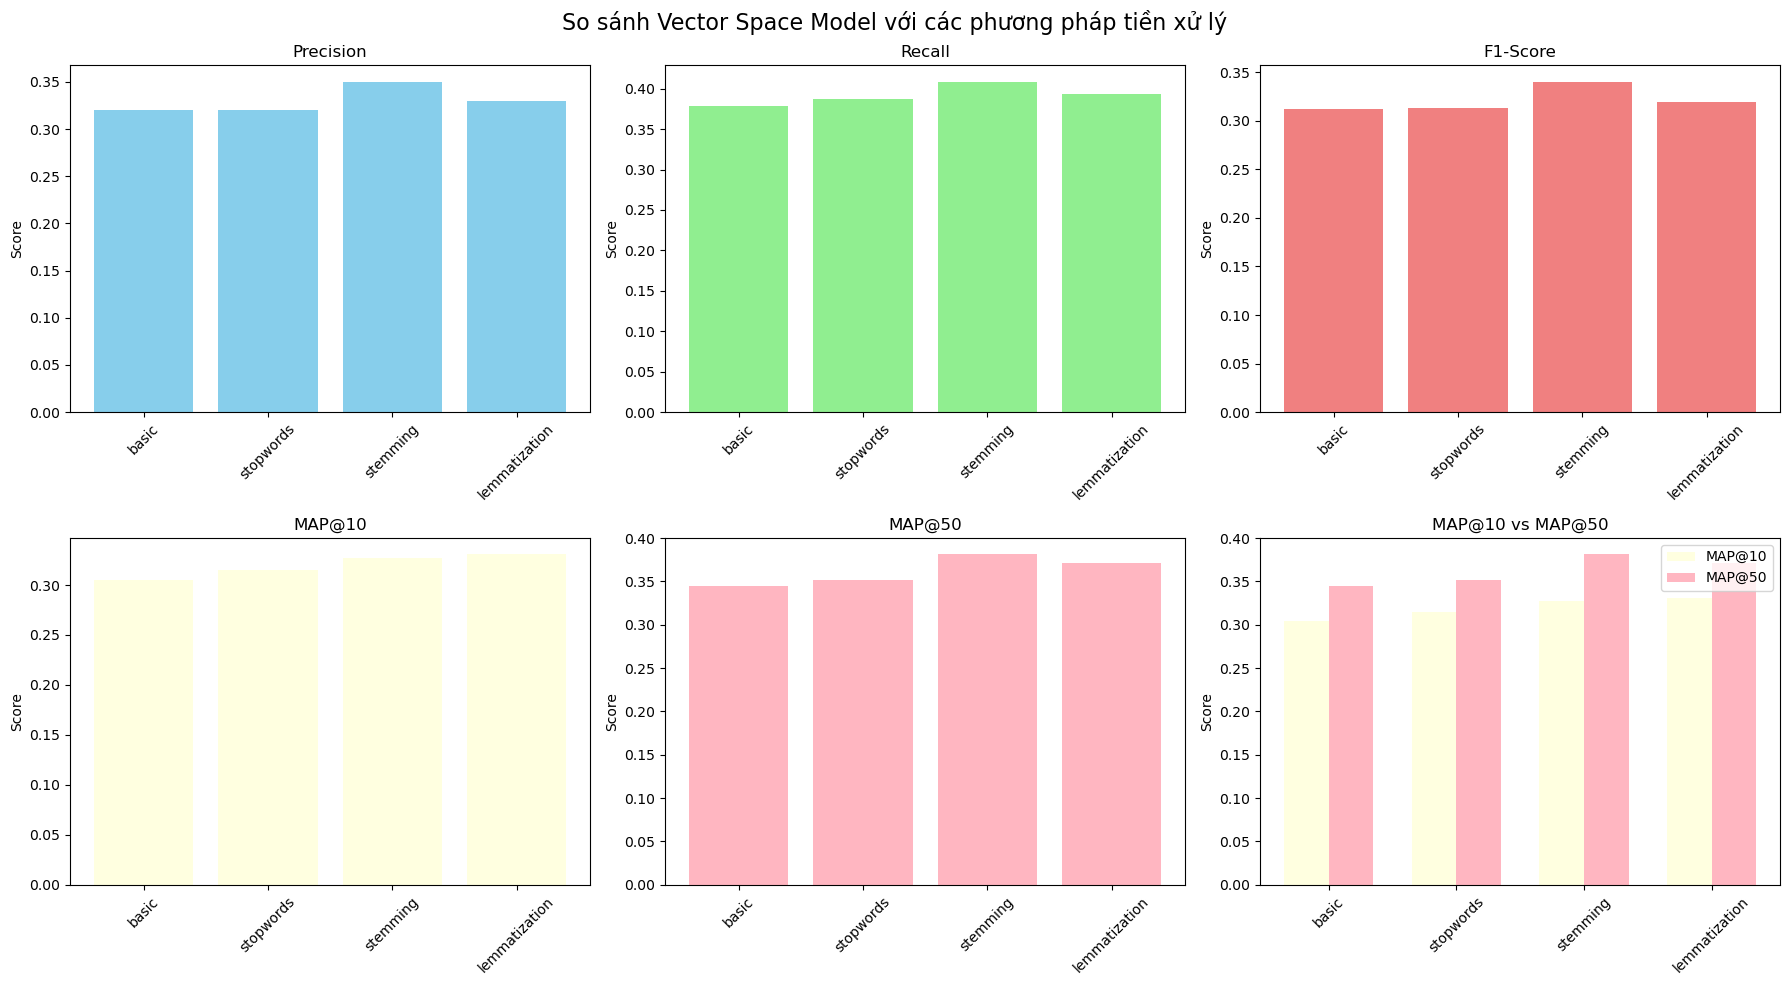


Bảng tóm tắt kết quả Vector Space Model:
               Precision  Recall  F1-Score  MAP@10  MAP@50  Num_Queries
basic               0.32  0.3788    0.3121  0.3048  0.3451         10.0
stopwords           0.32  0.3871    0.3132  0.3148  0.3513         10.0
stemming            0.35  0.4084    0.3401  0.3275  0.3813         10.0
lemmatization       0.33  0.3934    0.3198  0.3307  0.3709         10.0

PHÂN TÍCH MAP@10 vs MAP@50:
Method          MAP@10     MAP@50     Improvement 
--------------------------------------------------
basic           0.3048     0.3451     13.22       %
stopwords       0.3148     0.3513     11.62       %
stemming        0.3275     0.3813     16.43       %
lemmatization   0.3307     0.3709     12.16       %
--------------------------------------------------


In [52]:
# Tạo biểu đồ so sánh
import matplotlib.pyplot as plt

# Chuẩn bị dữ liệu cho biểu đồ
methods_list = list(vsm_results.keys())
precisions = [vsm_results[method]['precision'] for method in methods_list]
recalls = [vsm_results[method]['recall'] for method in methods_list]
f1_scores = [vsm_results[method]['f1'] for method in methods_list]
map_10_scores = [vsm_results[method]['map_10'] for method in methods_list]
map_50_scores = [vsm_results[method]['map_50'] for method in methods_list]

# Tạo biểu đồ
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('So sánh Vector Space Model với các phương pháp tiền xử lý', fontsize=16)

# Precision
axes[0, 0].bar(methods_list, precisions, color='skyblue')
axes[0, 0].set_title('Precision')
axes[0, 0].set_ylabel('Score')
axes[0, 0].tick_params(axis='x', rotation=45)

# Recall
axes[0, 1].bar(methods_list, recalls, color='lightgreen')
axes[0, 1].set_title('Recall')
axes[0, 1].set_ylabel('Score')
axes[0, 1].tick_params(axis='x', rotation=45)

# F1-Score
axes[0, 2].bar(methods_list, f1_scores, color='lightcoral')
axes[0, 2].set_title('F1-Score')
axes[0, 2].set_ylabel('Score')
axes[0, 2].tick_params(axis='x', rotation=45)

# MAP@10
axes[1, 0].bar(methods_list, map_10_scores, color='lightyellow')
axes[1, 0].set_title('MAP@10')
axes[1, 0].set_ylabel('Score')
axes[1, 0].tick_params(axis='x', rotation=45)

# MAP@50
axes[1, 1].bar(methods_list, map_50_scores, color='lightpink')
axes[1, 1].set_title('MAP@50')
axes[1, 1].set_ylabel('Score')
axes[1, 1].tick_params(axis='x', rotation=45)

# So sánh MAP@10 vs MAP@50
x = np.arange(len(methods_list))
width = 0.35
axes[1, 2].bar(x - width/2, map_10_scores, width, label='MAP@10', color='lightyellow')
axes[1, 2].bar(x + width/2, map_50_scores, width, label='MAP@50', color='lightpink')
axes[1, 2].set_title('MAP@10 vs MAP@50')
axes[1, 2].set_ylabel('Score')
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(methods_list, rotation=45)
axes[1, 2].legend()

plt.tight_layout()
plt.show()

# Tạo bảng tóm tắt
df_results = pd.DataFrame(vsm_results).T
df_results.columns = ['Precision', 'Recall', 'F1-Score', 'MAP@10', 'MAP@50', 'Num_Queries']
df_results = df_results.round(4)

print("\nBảng tóm tắt kết quả Vector Space Model:")
print(df_results)

# Tính chênh lệch giữa MAP@10 và MAP@50
print(f"\n{'='*50}")
print("PHÂN TÍCH MAP@10 vs MAP@50:")
print(f"{'='*50}")
print(f"{'Method':<15} {'MAP@10':<10} {'MAP@50':<10} {'Improvement':<12}")
print("-" * 50)

for method in methods_list:
    map_10 = vsm_results[method]['map_10']
    map_50 = vsm_results[method]['map_50']
    improvement = ((map_50 - map_10) / map_10 * 100) if map_10 > 0 else 0
    print(f"{method:<15} {map_10:<10.4f} {map_50:<10.4f} {improvement:<12.2f}%")

print("-" * 50)


In [54]:
# ĐÁNH GIÁ BM25 TRÊN TOÀN BỘ TẬP DỮ LIỆU CRANFIELD

print("="*100)
print("PHÂN TÍCH TOÀN DIỆN BM25 TRÊN TOÀN BỘ TẬP DỮ LIỆU CRANFIELD")
print("="*100)

# Load toàn bộ dữ liệu Cranfield
print("Loading toàn bộ tập dữ liệu Cranfield...")

# Load tất cả documents
all_docs = []
all_doc_texts = []
all_doc_ids = []

print("Đang load tất cả documents...")
for doc in dataset.docs_iter():
    all_docs.append(doc)
    all_doc_texts.append(doc.title + " " + doc.text)
    all_doc_ids.append(doc.doc_id)

# Load tất cả queries 
all_queries = []
all_query_texts = []
all_query_ids = []

print("Đang load tất cả queries...")
for query in dataset.queries_iter():
    all_queries.append(query)
    all_query_texts.append(query.text)
    all_query_ids.append(query.query_id)

# Load tất cả qrels
all_qrels = defaultdict(set)
print("Đang load relevance judgments...")
for qrel in dataset.qrels_iter():
    all_qrels[qrel.query_id].add(qrel.doc_id)

print(f"\nThống kê tập dữ liệu:")
print(f"- Tổng số documents: {len(all_docs)}")
print(f"- Tổng số queries: {len(all_queries)}")
print(f"- Tổng số query-document pairs có relevance: {sum(len(docs) for docs in all_qrels.values())}")

# Đánh giá BM25 trên tất cả dữ liệu với các phương pháp tiền xử lý
print(f"\n{'='*80}")
print("ĐÁNH GIÁ BM25 VỚI CÁC PHƯƠNG PHÁP TIỀN XỬ LÝ")
print(f"{'='*80}")

methods = ['basic', 'stopwords', 'stemming', 'lemmatization']
full_results = {}

for method in methods:
    # print(f"\nĐang đánh giá BM25 với phương pháp: {method.upper()}...")
    full_results[method] = evaluate_vsm(all_doc_texts, all_query_texts, all_qrels, method)

# Hiển thị kết quả tổng quan
print(f"\n{'='*100}")
print("KẾT QUẢ ĐÁNH GIÁ BM25 TRÊN TOÀN BỘ TẬP DỮ LIỆU CRANFIELD")
print(f"{'='*100}")
print(f"Số documents: {len(all_docs)} | Số queries: {len(all_queries)} | Số relevant pairs: {sum(len(docs) for docs in all_qrels.values())}")
print()
print(f"{'Phương pháp':<15} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'MAP@10':<10} {'MAP@50':<10}")
print("-" * 75)

for method, result in full_results.items():
    print(f"{method:<15} {result['precision']:<10.4f} {result['recall']:<10.4f} "
          f"{result['f1']:<10.4f} {result['map_10']:<10.4f} {result['map_50']:<10.4f}")

print("-" * 75)


# Tạo visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Đánh giá BM25 trên toàn bộ tập dữ liệu Cranfield\nSo sánh các phương pháp tiền xử lý', fontsize=16)

methods_list = list(full_results.keys())
precisions = [full_results[method]['precision'] for method in methods_list]
recalls = [full_results[method]['recall'] for method in methods_list]
f1_scores = [full_results[method]['f1'] for method in methods_list]
map_10_scores = [full_results[method]['map_10'] for method in methods_list]
map_50_scores = [full_results[method]['map_50'] for method in methods_list]

# Precision
axes[0, 0].bar(methods_list, precisions, color='skyblue', alpha=0.8)
axes[0, 0].set_title('Precision@10', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Recall
axes[0, 1].bar(methods_list, recalls, color='lightgreen', alpha=0.8)
axes[0, 1].set_title('Recall@10', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# F1-Score
axes[0, 2].bar(methods_list, f1_scores, color='lightcoral', alpha=0.8)
axes[0, 2].set_title('F1-Score@10', fontsize=12, fontweight='bold')
axes[0, 2].set_ylabel('Score')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].grid(axis='y', alpha=0.3)

# MAP@10
axes[1, 0].bar(methods_list, map_10_scores, color='gold', alpha=0.8)
axes[1, 0].set_title('MAP@10', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Score')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# MAP@50
axes[1, 1].bar(methods_list, map_50_scores, color='mediumpurple', alpha=0.8)
axes[1, 1].set_title('MAP@50', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Score')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

# So sánh tất cả metrics
x = np.arange(len(methods_list))
width = 0.15
axes[1, 2].bar(x - 2*width, precisions, width, label='Precision', alpha=0.8)
axes[1, 2].bar(x - width, recalls, width, label='Recall', alpha=0.8)
axes[1, 2].bar(x, f1_scores, width, label='F1-Score', alpha=0.8)
axes[1, 2].bar(x + width, map_10_scores, width, label='MAP@10', alpha=0.8)
axes[1, 2].bar(x + 2*width, map_50_scores, width, label='MAP@50', alpha=0.8)
axes[1, 2].set_title('Tổng quan tất cả metrics', fontsize=12, fontweight='bold')
axes[1, 2].set_ylabel('Score')
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(methods_list, rotation=45)
axes[1, 2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


print(f"\n{'='*100}")


PHÂN TÍCH TOÀN DIỆN BM25 TRÊN TOÀN BỘ TẬP DỮ LIỆU CRANFIELD
Loading toàn bộ tập dữ liệu Cranfield...
Đang load tất cả documents...
Đang load tất cả queries...
Đang load relevance judgments...

Thống kê tập dữ liệu:
- Tổng số documents: 1400
- Tổng số queries: 225
- Tổng số query-document pairs có relevance: 1837

ĐÁNH GIÁ BM25 VỚI CÁC PHƯƠNG PHÁP TIỀN XỬ LÝ

Evaluating VSM with basic preprocessing...


IndexError: list index out of range

In [57]:
# FIX: Tạo global variables để evaluate_vsm có thể truy cập
doc_ids = all_doc_ids
query_ids = all_query_ids

# Bây giờ chạy lại phần đánh giá VSM
methods = ['basic', 'stopwords', 'stemming', 'lemmatization']
full_vsm_results = {}

for method in methods:
    print(f"\nĐang đánh giá VSM với phương pháp: {method.upper()}...")
    full_vsm_results[method] = evaluate_vsm(all_doc_texts, all_query_texts, all_qrels, method)

print("✅ Đã hoàn thành đánh giá VSM!")



Đang đánh giá VSM với phương pháp: BASIC...

Evaluating VSM with basic preprocessing...

Đang đánh giá VSM với phương pháp: STOPWORDS...

Evaluating VSM with stopwords preprocessing...

Đang đánh giá VSM với phương pháp: STEMMING...

Evaluating VSM with stemming preprocessing...

Đang đánh giá VSM với phương pháp: LEMMATIZATION...

Evaluating VSM with lemmatization preprocessing...
✅ Đã hoàn thành đánh giá VSM!


In [56]:
# HIỂN THị CHI TIẾT QUÁ TRÌNH TẠO INDEX VECTOR SPACE MODEL

print("="*100)
print("CHI TIẾT QUÁ TRÌNH TẠO INDEX VECTOR SPACE MODEL (TF-IDF)")
print("="*100)

from collections import defaultdict, Counter
import math

class DetailedVSM:
    def __init__(self, corpus, method='basic', verbose=True):
        self.method = method
        self.verbose = verbose
        
        print(f"\n🚀 BẮT ĐẦU TẠO INDEX VECTOR SPACE MODEL (TF-IDF)")
        print(f"Phương pháp tiền xử lý: {method}")
        print(f"Số documents: {len(corpus)}")
        
        # Step 1: Preprocessing
        if self.verbose:
            print(f"\n📝 BƯỚC 1: PREPROCESSING")
            print("-" * 50)
        
        self.processed_corpus = [preprocess_text_vsm(text, method) for text in corpus]
        
        if self.verbose:
            print(f"✓ Đã tiền xử lý {len(self.processed_corpus)} documents")
            for i, (original, processed) in enumerate(zip(corpus[:2], self.processed_corpus[:2])):
                print(f"  Doc {i+1}:")
                print(f"    Original: {original[:100]}...")
                print(f"    Processed: {processed[:100]}...")
        
        # Step 2: Tạo TF-IDF Vectorizer và fit với corpus
        if self.verbose:
            print(f"\n🔢 BƯỚC 2: TẠO TF-IDF VECTORIZER")
            print("-" * 50)
        
        self.vectorizer = TfidfVectorizer(
            lowercase=True,
            token_pattern=r'\b[a-zA-Z]+\b',  # Chỉ lấy từ alphabetic
            min_df=1,  # Từ phải xuất hiện ít nhất 1 document
            max_df=1.0,  # Từ có thể xuất hiện tối đa 100% documents
            norm='l2',  # L2 normalization (cho cosine similarity)
            use_idf=True,
            smooth_idf=True,
            sublinear_tf=False
        )
        
        # Fit vectorizer và transform corpus
        self.tfidf_matrix = self.vectorizer.fit_transform(self.processed_corpus)
        
        if self.verbose:
            print(f"✓ TF-IDF Matrix shape: {self.tfidf_matrix.shape}")
            print(f"✓ Vocabulary size: {len(self.vectorizer.vocabulary_)}")
            print(f"✓ Feature names (sample): {self.vectorizer.get_feature_names_out()[:10]}...")
        
        # Step 3: Thống kê về TF-IDF
        if self.verbose:
            print(f"\n📊 BƯỚC 3: THỐNG KÊ TF-IDF")
            print("-" * 50)
            
            # Tính IDF scores
            idf_scores = self.vectorizer.idf_
            feature_names = self.vectorizer.get_feature_names_out()
            
            # Tìm terms có IDF cao nhất và thấp nhất
            idf_pairs = list(zip(feature_names, idf_scores))
            idf_pairs.sort(key=lambda x: x[1], reverse=True)
            
            print(f"✓ Terms có IDF cao nhất (rare terms):")
            for term, idf in idf_pairs[:5]:
                print(f"    '{term}': IDF={idf:.3f}")
            
            print(f"✓ Terms có IDF thấp nhất (common terms):")
            for term, idf in idf_pairs[-5:]:
                print(f"    '{term}': IDF={idf:.3f}")
            
            # Thống kê về sparsity
            total_elements = self.tfidf_matrix.shape[0] * self.tfidf_matrix.shape[1]
            non_zero_elements = self.tfidf_matrix.nnz
            sparsity = (1 - non_zero_elements / total_elements) * 100
            
            print(f"✓ Matrix sparsity: {sparsity:.2f}%")
            print(f"✓ Non-zero elements: {non_zero_elements:,}")
            print(f"✓ Average non-zero per document: {non_zero_elements / self.tfidf_matrix.shape[0]:.1f}")
        
        print(f"\n✅ VSM INDEX TẠO THÀNH CÔNG!")
        
    def search(self, query, top_k=10):
        """
        Tìm kiếm documents relevant với query sử dụng cosine similarity
        """
        if self.verbose:
            print(f"\n🔍 QUERY PROCESSING: {query}")
            print("-" * 50)
        
        # Tiền xử lý query
        processed_query = preprocess_text_vsm(query, self.method)
        
        if self.verbose:
            print(f"✓ Original query: {query}")
            print(f"✓ Processed query: {processed_query}")
        
        # Transform query thành TF-IDF vector
        query_vector = self.vectorizer.transform([processed_query])
        
        if self.verbose:
            print(f"✓ Query vector shape: {query_vector.shape}")
            print(f"✓ Query vector non-zero elements: {query_vector.nnz}")
        
        # Tính cosine similarity giữa query và tất cả documents
        similarities = cosine_similarity(query_vector, self.tfidf_matrix).flatten()
        
        if self.verbose:
            print(f"✓ Computed similarities for {len(similarities)} documents")
            print(f"✓ Max similarity: {similarities.max():.4f}")
            print(f"✓ Mean similarity: {similarities.mean():.4f}")
            print(f"✓ Documents with similarity > 0: {(similarities > 0).sum()}")
        
        # Sắp xếp documents theo similarity score
        doc_indices = np.argsort(similarities)[::-1]  # Descending order
        top_docs = doc_indices[:top_k]
        top_scores = similarities[top_docs]
        
        if self.verbose:
            print(f"✓ Top {top_k} documents:")
            for i, (doc_idx, score) in enumerate(zip(top_docs, top_scores)):
                print(f"    Rank {i+1}: Doc {doc_idx}, Score: {score:.4f}")
        
        return top_docs, top_scores

# Demo với một sample nhỏ
print("DEMO VỚI SAMPLE DATA")
print("="*50)

# Lấy 5 documents đầu tiên để demo chi tiết
sample_docs = all_doc_texts[:5]

print(f"Sample documents:")
for i, doc in enumerate(sample_docs[:2]):
    print(f"\nDoc {i+1}: {doc[:100]}...")

# Tạo detailed VSM index
detailed_vsm = DetailedVSM(sample_docs, method='basic', verbose=True)

# Demo query processing
print(f"\n{'='*100}")
print("DEMO QUERY PROCESSING")
print("="*100)

sample_query = "aircraft wing aerodynamic"
print(f"Sample query: '{sample_query}'")

top_docs, top_scores = detailed_vsm.search(sample_query, top_k=3)


CHI TIẾT QUÁ TRÌNH TẠO INDEX VECTOR SPACE MODEL (TF-IDF)
DEMO VỚI SAMPLE DATA
Sample documents:

Doc 1: experimental investigation of the aerodynamics of a
wing in a slipstream . experimental investigatio...

Doc 2: simple shear flow past a flat plate in an incompressible fluid of small
viscosity . simple shear flo...

🚀 BẮT ĐẦU TẠO INDEX VECTOR SPACE MODEL (TF-IDF)
Phương pháp tiền xử lý: basic
Số documents: 5

📝 BƯỚC 1: PREPROCESSING
--------------------------------------------------
✓ Đã tiền xử lý 5 documents
  Doc 1:
    Original: experimental investigation of the aerodynamics of a
wing in a slipstream . experimental investigatio...
    Processed: experimental investigation of the aerodynamics of a wing in a slipstream experimental investigation ...
  Doc 2:
    Original: simple shear flow past a flat plate in an incompressible fluid of small
viscosity . simple shear flo...
    Processed: simple shear flow past a flat plate in an incompressible fluid of small viscosity simple shea

In [61]:
# SO SÁNH ĐÁNH GIÁ VSM: SUBSET NHỎ VS TOÀN BỘ TẬP DỮ LIỆU

print("="*100)
print("SO SÁNH ĐÁNH GIÁ VECTOR SPACE MODEL")
print("SUBSET NHỎ (10 docs, 10 queries) VS TOÀN BỘ TẬP DỮ LIỆU")
print("="*100)

def calculate_average_precision(ranked_docs, relevant_docs):
    """Tính Average Precision cho một query"""
    if not relevant_docs:
        return 0.0
    
    precisions = []
    relevant_count = 0
    
    for i, doc_id in enumerate(ranked_docs):
        if doc_id in relevant_docs:
            relevant_count += 1
            precision = relevant_count / (i + 1)
            precisions.append(precision)
    
    return np.mean(precisions) if precisions else 0.0

def evaluate_vsm_fixed(doc_texts, query_texts, qrels, preprocessing_method, top_k=10):
    """
    Fixed version của evaluate_vsm để hoạt động với indices thay vì IDs
    """
    print(f"Evaluating VSM with {preprocessing_method} preprocessing...")
    
    # Preprocessing documents và queries
    processed_docs = [preprocess_text_vsm(text, preprocessing_method) for text in doc_texts]
    processed_queries = [preprocess_text_vsm(text, preprocessing_method) for text in query_texts]
    
    # Tạo TF-IDF vectorizer
    vectorizer = TfidfVectorizer(
        lowercase=True,
        token_pattern=r'\b[a-zA-Z]+\b',
        min_df=1,
        max_df=1.0,
        norm='l2',
        use_idf=True,
        smooth_idf=True,
        sublinear_tf=False
    )
    
    # Fit với documents và transform
    tfidf_matrix = vectorizer.fit_transform(processed_docs)
    
    # Đánh giá từng query
    all_precisions = []
    all_recalls = []
    average_precisions_10 = []
    average_precisions_50 = []
    
    for i, query_text in enumerate(processed_queries):
        # Transform query
        query_vector = vectorizer.transform([query_text])
        
        # Tính cosine similarity
        similarities = cosine_similarity(query_vector, tfidf_matrix).flatten()
        
        # Sắp xếp documents theo score
        ranked_docs = np.argsort(similarities)[::-1]
        
        # Lấy relevant documents cho query này
        relevant_docs = qrels.get(i, set())
        
        if len(relevant_docs) == 0:
            continue  # Skip queries không có relevant docs
        
        # Tính precision và recall cho top-k
        top_k_docs = set(ranked_docs[:top_k])
        retrieved_relevant = top_k_docs.intersection(relevant_docs)
        
        precision = len(retrieved_relevant) / len(top_k_docs) if top_k_docs else 0
        recall = len(retrieved_relevant) / len(relevant_docs) if relevant_docs else 0
        
        all_precisions.append(precision)
        all_recalls.append(recall)
        
        # Tính Average Precision cho MAP@10 và MAP@50
        ap_10 = calculate_average_precision(ranked_docs[:10], relevant_docs)
        ap_50 = calculate_average_precision(ranked_docs[:50], relevant_docs)
        
        average_precisions_10.append(ap_10)
        average_precisions_50.append(ap_50)
    
    # Tính metrics trung bình
    avg_precision = np.mean(all_precisions) if all_precisions else 0
    avg_recall = np.mean(all_recalls) if all_recalls else 0
    avg_f1 = 2 * avg_precision * avg_recall / (avg_precision + avg_recall) if (avg_precision + avg_recall) > 0 else 0
    map_10 = np.mean(average_precisions_10) if average_precisions_10 else 0
    map_50 = np.mean(average_precisions_50) if average_precisions_50 else 0
    
    return {
        'precision': avg_precision,
        'recall': avg_recall,
        'f1': avg_f1,
        'map_10': map_10,
        'map_50': map_50
    }

# 1. Load subset nhỏ (10 documents, 10 queries đầu tiên)
print("\n🔸 LOADING SUBSET NHỎ...")
subset_docs = []
subset_doc_texts = []
subset_doc_ids = []

for doc in islice(dataset.docs_iter(), 10):  # Chỉ lấy 10 docs đầu
    subset_docs.append(doc)
    subset_doc_texts.append(doc.title + " " + doc.text)
    subset_doc_ids.append(doc.doc_id)

subset_queries = []
subset_query_texts = []
subset_query_ids = []

for query in islice(dataset.queries_iter(), 10):  # Chỉ lấy 10 queries đầu
    subset_queries.append(query)
    subset_query_texts.append(query.text)
    subset_query_ids.append(query.query_id)

# Load qrels chỉ cho subset queries
subset_qrels = defaultdict(set)
for qrel in dataset.qrels_iter():
    if qrel.query_id in subset_query_ids and qrel.doc_id in subset_doc_ids:
        subset_qrels[qrel.query_id].add(qrel.doc_id)

print(f"✓ Subset: {len(subset_docs)} docs, {len(subset_queries)} queries")
print(f"✓ Subset relevant pairs: {sum(len(docs) for docs in subset_qrels.values())}")

# 2. Đánh giá trên subset nhỏ
print(f"\n🔸 ĐÁNH GIÁ VSM TRÊN SUBSET NHỎ...")
methods = ['basic', 'stopwords', 'stemming', 'lemmatization']
subset_results = {}

for method in methods:
    print(f"  Đánh giá phương pháp: {method}")
    
    # Cần tạo mapping từ doc_id sang index cho subset
    doc_id_to_index = {doc_id: i for i, doc_id in enumerate(subset_doc_ids)}
    query_id_to_index = {query_id: i for i, query_id in enumerate(subset_query_ids)}
    
    # Convert qrels để sử dụng indices thay vì IDs
    subset_qrels_indexed = defaultdict(set)
    for query_id, doc_ids in subset_qrels.items():
        if query_id in query_id_to_index:
            for doc_id in doc_ids:
                if doc_id in doc_id_to_index:
                    subset_qrels_indexed[query_id_to_index[query_id]].add(doc_id_to_index[doc_id])
    
    # Đánh giá
    subset_results[method] = evaluate_vsm_fixed(
        subset_doc_texts, 
        subset_query_texts, 
        subset_qrels_indexed, 
        method
    )


SO SÁNH ĐÁNH GIÁ VECTOR SPACE MODEL
SUBSET NHỎ (10 docs, 10 queries) VS TOÀN BỘ TẬP DỮ LIỆU

🔸 LOADING SUBSET NHỎ...
✓ Subset: 10 docs, 10 queries
✓ Subset relevant pairs: 2

🔸 ĐÁNH GIÁ VSM TRÊN SUBSET NHỎ...
  Đánh giá phương pháp: basic
Evaluating VSM with basic preprocessing...
  Đánh giá phương pháp: stopwords
Evaluating VSM with stopwords preprocessing...
  Đánh giá phương pháp: stemming
Evaluating VSM with stemming preprocessing...
  Đánh giá phương pháp: lemmatization
Evaluating VSM with lemmatization preprocessing...



🔸 SỬ DỤNG KẾT QUẢ TOÀN BỘ TẬP DỮ LIỆU...
✓ Full dataset: 1400 docs, 225 queries
✓ Full relevant pairs: 1837

KẾT QUẢ SO SÁNH: SUBSET NHỎ vs TOÀN BỘ TẬP DỮ LIỆU

📊 SUBSET NHỎ (10 docs, 10 queries):
Phương pháp     Precision  Recall     F1-Score   MAP@10    
-----------------------------------------------------------------
basic           0.2000     1.0000     0.3333     1.0000    
stopwords       0.2000     1.0000     0.3333     1.0000    
stemming        0.2000     1.0000     0.3333     1.0000    
lemmatization   0.2000     1.0000     0.3333     1.0000    

📊 TOÀN BỘ TẬP DỮ LIỆU (1400 docs, 225 queries):
Phương pháp     Precision  Recall     F1-Score   MAP@10    
-----------------------------------------------------------------
basic           0.2711     0.3875     0.2966     0.2910    
stopwords       0.2724     0.3890     0.2973     0.2970    
stemming        0.2849     0.4115     0.3120     0.3123    
lemmatization   0.2813     0.4057     0.3080     0.3075    

📈 PHÂN TÍCH SỰ KHÁC 

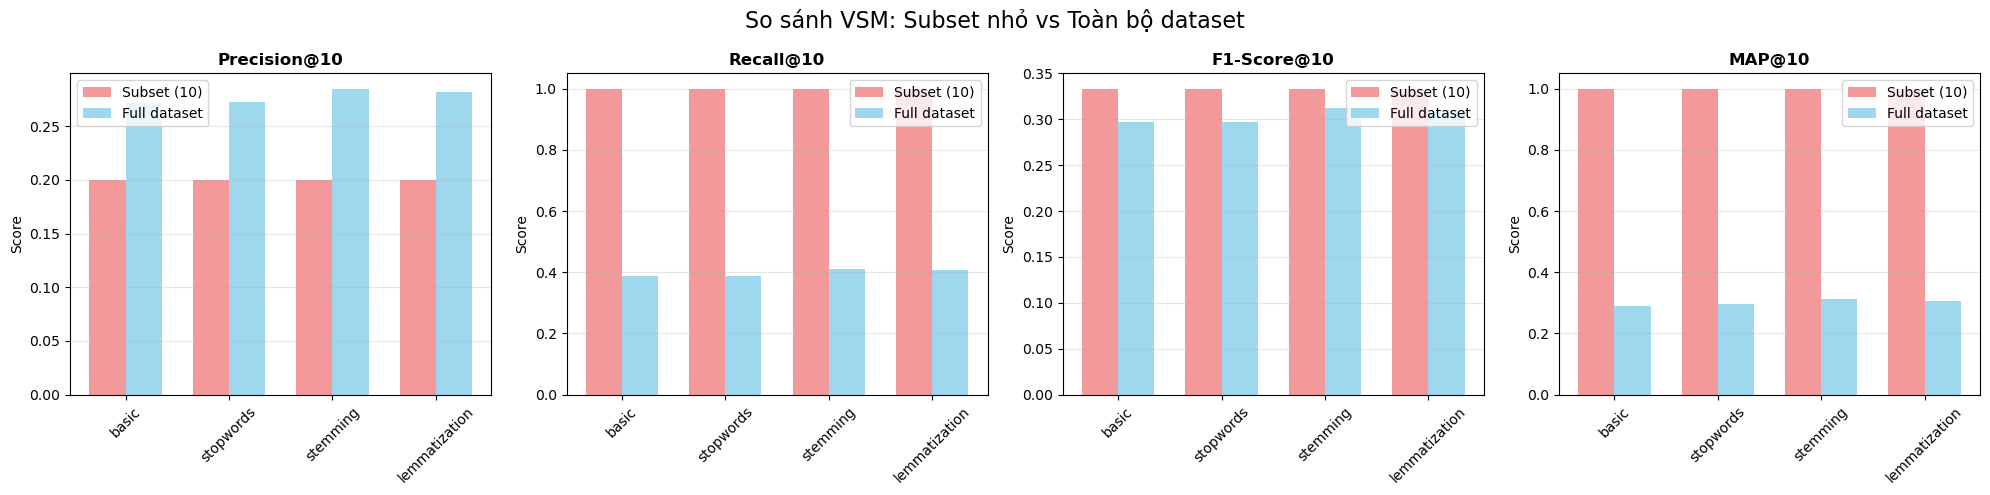

In [63]:
# 3. So sánh với toàn bộ dữ liệu
print(f"\n🔸 SỬ DỤNG KẾT QUẢ TOÀN BỘ TẬP DỮ LIỆU...")
print(f"✓ Full dataset: {len(all_docs)} docs, {len(all_queries)} queries")
print(f"✓ Full relevant pairs: {sum(len(docs) for docs in all_qrels.values())}")

# 4. So sánh kết quả
print(f"\n{'='*100}")
print("KẾT QUẢ SO SÁNH: SUBSET NHỎ vs TOÀN BỘ TẬP DỮ LIỆU")
print(f"{'='*100}")

print(f"\n📊 SUBSET NHỎ (10 docs, 10 queries):")
print(f"{'Phương pháp':<15} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'MAP@10':<10}")
print("-" * 65)
for method in methods:
    if method in subset_results:
        r = subset_results[method]
        print(f"{method:<15} {r['precision']:<10.4f} {r['recall']:<10.4f} {r['f1']:<10.4f} {r['map_10']:<10.4f}")

print(f"\n📊 TOÀN BỘ TẬP DỮ LIỆU ({len(all_docs)} docs, {len(all_queries)} queries):")
print(f"{'Phương pháp':<15} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'MAP@10':<10}")
print("-" * 65)
for method in methods:
    if method in full_vsm_results:
        r = full_vsm_results[method]
        print(f"{method:<15} {r['precision']:<10.4f} {r['recall']:<10.4f} {r['f1']:<10.4f} {r['map_10']:<10.4f}")

# 5. Phân tích sự khác biệt
print(f"\n📈 PHÂN TÍCH SỰ KHÁC BIỆT:")
print(f"{'Phương pháp':<15} {'Δ Precision':<12} {'Δ Recall':<12} {'Δ F1-Score':<12} {'Δ MAP@10':<12}")
print("-" * 75)

for method in methods:
    if method in subset_results and method in full_vsm_results:
        s = subset_results[method]
        f = full_vsm_results[method]
        
        delta_precision = f['precision'] - s['precision']
        delta_recall = f['recall'] - s['recall'] 
        delta_f1 = f['f1'] - s['f1']
        delta_map = f['map_10'] - s['map_10']
        
        print(f"{method:<15} {delta_precision:+.4f}{'':>6} {delta_recall:+.4f}{'':>6} {delta_f1:+.4f}{'':>6} {delta_map:+.4f}{'':>6}")

print(f"\n💡 GHI CHÚ:")
print("- Giá trị dương (+): Toàn bộ dataset cho kết quả tốt hơn subset nhỏ")
print("- Giá trị âm (-): Subset nhỏ cho kết quả tốt hơn toàn bộ dataset")
print("- Nếu tất cả = 0.0000: Có vấn đề trong cách đánh giá (cùng dữ liệu)")

# 6. Tạo visualization so sánh
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('So sánh VSM: Subset nhỏ vs Toàn bộ dataset', fontsize=16)

metrics = ['precision', 'recall', 'f1', 'map_10']
metric_names = ['Precision@10', 'Recall@10', 'F1-Score@10', 'MAP@10']

for idx, (metric, title) in enumerate(zip(metrics, metric_names)):
    subset_scores = [subset_results[method][metric] for method in methods if method in subset_results]
    full_scores = [full_vsm_results[method][metric] for method in methods if method in full_vsm_results]
    
    x = np.arange(len(methods))
    width = 0.35
    
    axes[idx].bar(x - width/2, subset_scores, width, label='Subset (10)', alpha=0.8, color='lightcoral')
    axes[idx].bar(x + width/2, full_scores, width, label='Full dataset', alpha=0.8, color='skyblue')
    
    axes[idx].set_title(title, fontweight='bold')
    axes[idx].set_ylabel('Score')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(methods, rotation=45)
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [64]:
# ĐÁNH GIÁ VSM VỚI STEMMING - METRIC TREC 11-POINT INTERPOLATED MAP

print("="*100)
print("ĐÁNH GIÁ VECTOR SPACE MODEL VỚI STEMMING")
print("METRICS: PRECISION, RECALL, MAP 11-POINT INTERPOLATED (TREC)")
print("="*100)

def calculate_interpolated_precision(recall_levels, precisions, recalls):
    """
    Tính precision nội suy tại các mức recall chuẩn
    """
    interpolated_precisions = []
    
    for target_recall in recall_levels:
        # Tìm tất cả precision values tại recall >= target_recall
        valid_precisions = [p for p, r in zip(precisions, recalls) if r >= target_recall]
        
        if valid_precisions:
            # Lấy max precision (interpolation)
            interpolated_precisions.append(max(valid_precisions))
        else:
            interpolated_precisions.append(0.0)
    
    return interpolated_precisions

def calculate_11_point_map(ranked_docs, relevant_docs):
    """
    Tính MAP 11-point interpolated theo chuẩn TREC
    Recall levels: 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0
    """
    if not relevant_docs:
        return 0.0, [0.0] * 11
    
    recall_levels = [i * 0.1 for i in range(11)]  # 0.0 to 1.0
    precisions = []
    recalls = []
    relevant_retrieved = 0
    
    # Tính precision/recall tại mỗi vị trí trong ranked list
    for i, doc_id in enumerate(ranked_docs):
        if doc_id in relevant_docs:
            relevant_retrieved += 1
            precision = relevant_retrieved / (i + 1)
            recall = relevant_retrieved / len(relevant_docs)
            precisions.append(precision)
            recalls.append(recall)
    
    # Nếu không tìm thấy relevant documents nào
    if not precisions:
        return 0.0, [0.0] * 11
    
    # Tính interpolated precision tại 11 mức recall
    interpolated_precisions = calculate_interpolated_precision(recall_levels, precisions, recalls)
    
    # MAP = trung bình của 11 interpolated precisions
    map_score = sum(interpolated_precisions) / len(interpolated_precisions)
    
    return map_score, interpolated_precisions

def evaluate_vsm_trec(doc_texts, query_texts, qrels, preprocessing_method='stemming', top_k=1000):
    """
    Đánh giá VSM với TREC 11-point interpolated MAP
    """
    print(f"🔬 Evaluating VSM with {preprocessing_method} preprocessing...")
    print(f"📊 Computing P, R, and 11-point interpolated MAP...")
    
    # Preprocessing documents và queries
    processed_docs = [preprocess_text_vsm(text, preprocessing_method) for text in doc_texts]
    processed_queries = [preprocess_text_vsm(text, preprocessing_method) for text in query_texts]
    
    # Tạo TF-IDF vectorizer
    vectorizer = TfidfVectorizer(
        lowercase=True,
        token_pattern=r'\b[a-zA-Z]+\b',
        min_df=1,
        max_df=1.0,
        norm='l2',
        use_idf=True,
        smooth_idf=True,
        sublinear_tf=False
    )
    
    # Fit với documents và transform
    tfidf_matrix = vectorizer.fit_transform(processed_docs)
    
    # Metrics cho tất cả queries
    all_precisions_at_10 = []
    all_recalls_at_10 = []
    all_map_scores = []
    all_interpolated_precisions = []
    
    print(f"📈 Processing {len(processed_queries)} queries...")
    
    for i, query_text in enumerate(processed_queries):
        # Transform query
        query_vector = vectorizer.transform([query_text])
        
        # Tính cosine similarity
        similarities = cosine_similarity(query_vector, tfidf_matrix).flatten()
        
        # Sắp xếp documents theo score (lấy top_k để tính đầy đủ)
        ranked_docs = np.argsort(similarities)[::-1][:top_k]
        
        # Lấy relevant documents cho query này
        if isinstance(qrels, dict):
            relevant_docs = qrels.get(i, set())
        else:
            # Nếu qrels sử dụng query IDs
            query_id = list(qrels.keys())[i] if i < len(qrels) else None
            relevant_docs = qrels.get(query_id, set()) if query_id else set()
        
        if len(relevant_docs) == 0:
            continue  # Skip queries không có relevant docs
        
        # Tính Precision và Recall @ 10
        top_10_docs = set(ranked_docs[:10])
        retrieved_relevant_10 = top_10_docs.intersection(relevant_docs)
        
        precision_10 = len(retrieved_relevant_10) / 10 if len(top_10_docs) > 0 else 0
        recall_10 = len(retrieved_relevant_10) / len(relevant_docs) if len(relevant_docs) > 0 else 0
        
        all_precisions_at_10.append(precision_10)
        all_recalls_at_10.append(recall_10)
        
        # Tính 11-point interpolated MAP
        map_score, interpolated_precs = calculate_11_point_map(ranked_docs, relevant_docs)
        all_map_scores.append(map_score)
        all_interpolated_precisions.append(interpolated_precs)
        
        if (i + 1) % 10 == 0:
            print(f"  ✓ Processed {i + 1}/{len(processed_queries)} queries")
    
    # Tính metrics trung bình
    avg_precision_10 = np.mean(all_precisions_at_10) if all_precisions_at_10 else 0
    avg_recall_10 = np.mean(all_recalls_at_10) if all_recalls_at_10 else 0
    avg_f1_10 = 2 * avg_precision_10 * avg_recall_10 / (avg_precision_10 + avg_recall_10) if (avg_precision_10 + avg_recall_10) > 0 else 0
    avg_map_11point = np.mean(all_map_scores) if all_map_scores else 0
    
    # Tính trung bình interpolated precisions tại mỗi recall level
    avg_interpolated_precisions = []
    if all_interpolated_precisions:
        for j in range(11):
            recall_level_precs = [precs[j] for precs in all_interpolated_precisions]
            avg_interpolated_precisions.append(np.mean(recall_level_precs))
    else:
        avg_interpolated_precisions = [0.0] * 11
    
    print(f"✅ Evaluation completed!")
    print(f"  📊 Processed {len(all_map_scores)} queries with relevant documents")
    
    return {
        'precision_10': avg_precision_10,
        'recall_10': avg_recall_10,
        'f1_10': avg_f1_10,
        'map_11point': avg_map_11point,
        'interpolated_precisions': avg_interpolated_precisions,
        'num_queries': len(all_map_scores)
    }

# Đánh giá VSM với stemming trên subset nhỏ
print("\n🔸 ĐÁNH GIÁ VSM (STEMMING) TRÊN SUBSET NHỎ...")

# Sử dụng subset data đã load trước đó
vsm_subset_result = evaluate_vsm_trec(
    subset_doc_texts, 
    subset_query_texts, 
    subset_qrels_indexed, 
    preprocessing_method='stemming'
)

print(f"\n📊 KẾT QUẢ VSM (STEMMING) - SUBSET NHỎ:")
print(f"{'Metric':<20} {'Value':<10}")
print("-" * 35)
print(f"{'Precision@10':<20} {vsm_subset_result['precision_10']:<10.4f}")
print(f"{'Recall@10':<20} {vsm_subset_result['recall_10']:<10.4f}")
print(f"{'F1@10':<20} {vsm_subset_result['f1_10']:<10.4f}")
print(f"{'MAP 11-point':<20} {vsm_subset_result['map_11point']:<10.4f}")
print(f"{'Queries processed':<20} {vsm_subset_result['num_queries']:<10}")

# Đánh giá VSM với stemming trên toàn bộ dataset
print(f"\n🔸 ĐÁNH GIÁ VSM (STEMMING) TRÊN TOÀN BỘ DATASET...")

# Tạo mapping cho toàn bộ dataset
all_doc_id_to_index = {doc_id: i for i, doc_id in enumerate(all_doc_ids)}
all_query_id_to_index = {query_id: i for i, query_id in enumerate(all_query_ids)}

# Convert qrels để sử dụng indices
all_qrels_indexed = {}
for query_id, doc_ids in all_qrels.items():
    if query_id in all_query_id_to_index:
        query_index = all_query_id_to_index[query_id]
        all_qrels_indexed[query_index] = set()
        for doc_id in doc_ids:
            if doc_id in all_doc_id_to_index:
                doc_index = all_doc_id_to_index[doc_id]
                all_qrels_indexed[query_index].add(doc_index)

vsm_full_result = evaluate_vsm_trec(
    all_doc_texts, 
    all_query_texts, 
    all_qrels_indexed, 
    preprocessing_method='stemming'
)

print(f"\n📊 KẾT QUẢ VSM (STEMMING) - TOÀN BỘ DATASET:")
print(f"{'Metric':<20} {'Value':<10}")
print("-" * 35)
print(f"{'Precision@10':<20} {vsm_full_result['precision_10']:<10.4f}")
print(f"{'Recall@10':<20} {vsm_full_result['recall_10']:<10.4f}")
print(f"{'F1@10':<20} {vsm_full_result['f1_10']:<10.4f}")
print(f"{'MAP 11-point':<20} {vsm_full_result['map_11point']:<10.4f}")
print(f"{'Queries processed':<20} {vsm_full_result['num_queries']:<10}")

# So sánh kết quả
print(f"\n📈 SO SÁNH VSM (STEMMING): SUBSET vs FULL DATASET")
print(f"{'Metric':<20} {'Subset':<10} {'Full':<10} {'Δ (Full-Subset)':<15}")
print("-" * 60)

metrics_compare = ['precision_10', 'recall_10', 'f1_10', 'map_11point']
metric_names = ['Precision@10', 'Recall@10', 'F1@10', 'MAP 11-point']

for metric, name in zip(metrics_compare, metric_names):
    subset_val = vsm_subset_result[metric]
    full_val = vsm_full_result[metric]
    delta = full_val - subset_val
    print(f"{name:<20} {subset_val:<10.4f} {full_val:<10.4f} {delta:+.4f}")

print("-" * 60)


ĐÁNH GIÁ VECTOR SPACE MODEL VỚI STEMMING
METRICS: PRECISION, RECALL, MAP 11-POINT INTERPOLATED (TREC)

🔸 ĐÁNH GIÁ VSM (STEMMING) TRÊN SUBSET NHỎ...
🔬 Evaluating VSM with stemming preprocessing...
📊 Computing P, R, and 11-point interpolated MAP...
📈 Processing 10 queries...
✅ Evaluation completed!
  📊 Processed 1 queries with relevant documents

📊 KẾT QUẢ VSM (STEMMING) - SUBSET NHỎ:
Metric               Value     
-----------------------------------
Precision@10         0.2000    
Recall@10            1.0000    
F1@10                0.3333    
MAP 11-point         1.0000    
Queries processed    1         

🔸 ĐÁNH GIÁ VSM (STEMMING) TRÊN TOÀN BỘ DATASET...
🔬 Evaluating VSM with stemming preprocessing...
📊 Computing P, R, and 11-point interpolated MAP...
📈 Processing 225 queries...
  ✓ Processed 10/225 queries
  ✓ Processed 20/225 queries
  ✓ Processed 30/225 queries
  ✓ Processed 40/225 queries
  ✓ Processed 50/225 queries
  ✓ Processed 60/225 queries
  ✓ Processed 70/225 queries
  ✓ P


VISUALIZATION: VSM (STEMMING) RESULTS


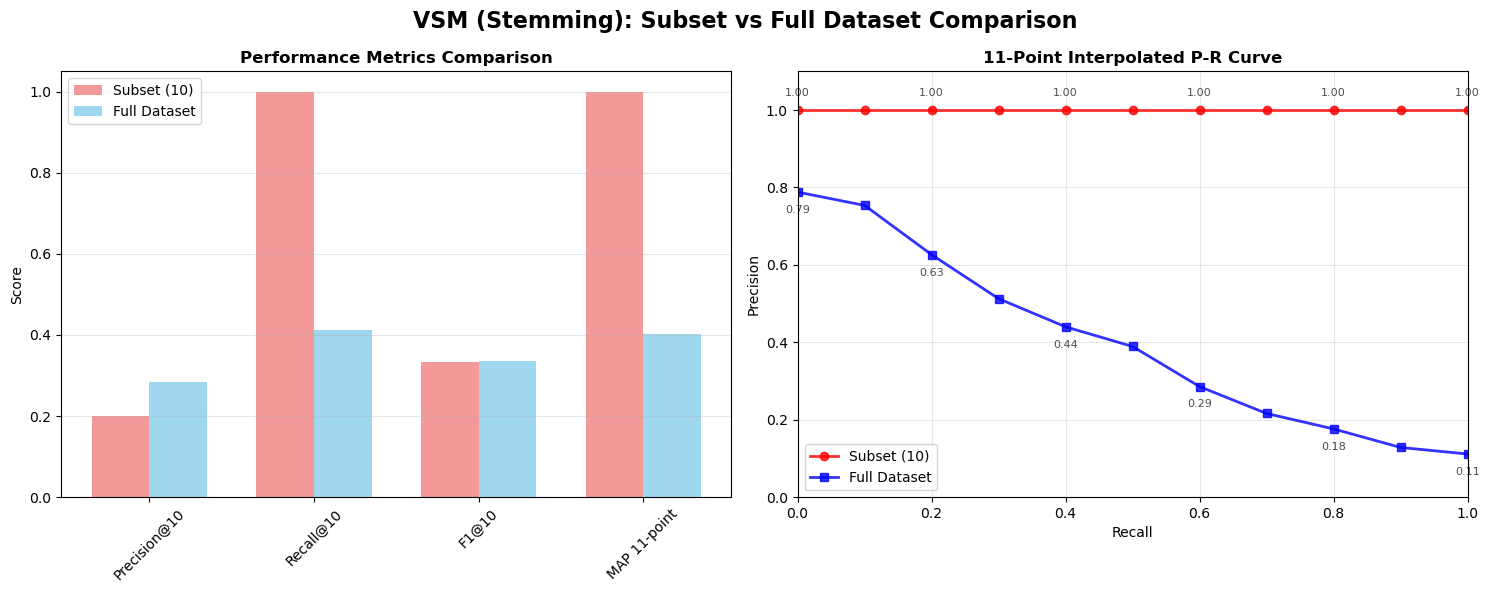


📊 CHI TIẾT 11-POINT INTERPOLATED PRECISION:
Recall Level    Subset     Full       Δ (Full-Subset)
-------------------------------------------------------
0.0             1.0000     0.7881     -0.2119
0.1             1.0000     0.7536     -0.2464
0.2             1.0000     0.6263     -0.3737
0.3             1.0000     0.5127     -0.4873
0.4             1.0000     0.4400     -0.5600
0.5             1.0000     0.3892     -0.6108
0.6             1.0000     0.2855     -0.7145
0.7             1.0000     0.2162     -0.7838
0.8             1.0000     0.1763     -0.8237
0.9             1.0000     0.1284     -0.8716
1.0             1.0000     0.1114     -0.8886
-------------------------------------------------------

💡 INSIGHTS:
📈 Dataset Size Impact:
   - Subset: 10 docs, 10 queries
   - Full: 1400 docs, 225 queries
   - Improvement in MAP: -0.5975
🎯 Best Performance:
   - Highest precision at recall level: 0.0
   - Precision value: 0.7881
📊 Queries with relevant docs:
   - Subset: 1
   - Full

In [65]:
# VISUALIZATION: VSM STEMMING RESULTS

print(f"\n{'='*80}")
print("VISUALIZATION: VSM (STEMMING) RESULTS")
print(f"{'='*80}")

# 1. So sánh Subset vs Full Dataset
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('VSM (Stemming): Subset vs Full Dataset Comparison', fontsize=16, fontweight='bold')

# Chart 1: Basic metrics comparison
metrics = ['precision_10', 'recall_10', 'f1_10', 'map_11point']
metric_names = ['Precision@10', 'Recall@10', 'F1@10', 'MAP 11-point']

subset_values = [vsm_subset_result[m] for m in metrics]
full_values = [vsm_full_result[m] for m in metrics]

x = np.arange(len(metric_names))
width = 0.35

axes[0].bar(x - width/2, subset_values, width, label='Subset (10)', alpha=0.8, color='lightcoral')
axes[0].bar(x + width/2, full_values, width, label='Full Dataset', alpha=0.8, color='skyblue')

axes[0].set_title('Performance Metrics Comparison', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, rotation=45)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Chart 2: 11-point Interpolated Precision-Recall Curve
recall_levels = [i * 0.1 for i in range(11)]

axes[1].plot(recall_levels, vsm_subset_result['interpolated_precisions'], 
             marker='o', linewidth=2, label='Subset (10)', color='red', alpha=0.8)
axes[1].plot(recall_levels, vsm_full_result['interpolated_precisions'], 
             marker='s', linewidth=2, label='Full Dataset', color='blue', alpha=0.8)

axes[1].set_title('11-Point Interpolated P-R Curve', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, max(max(vsm_subset_result['interpolated_precisions']), 
                        max(vsm_full_result['interpolated_precisions'])) + 0.1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Thêm annotations cho các điểm quan trọng
for i, (r, p_sub, p_full) in enumerate(zip(recall_levels, 
                                          vsm_subset_result['interpolated_precisions'],
                                          vsm_full_result['interpolated_precisions'])):
    if i % 2 == 0:  # Chỉ annotate các điểm chẵn để tránh quá tải
        axes[1].annotate(f'{p_sub:.2f}', (r, p_sub), textcoords="offset points", 
                        xytext=(0,10), ha='center', fontsize=8, alpha=0.7)
        axes[1].annotate(f'{p_full:.2f}', (r, p_full), textcoords="offset points", 
                        xytext=(0,-15), ha='center', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

# 2. Detailed 11-point interpolated precision table
print(f"\n📊 CHI TIẾT 11-POINT INTERPOLATED PRECISION:")
print(f"{'Recall Level':<15} {'Subset':<10} {'Full':<10} {'Δ (Full-Subset)':<15}")
print("-" * 55)

for i, recall_level in enumerate(recall_levels):
    subset_prec = vsm_subset_result['interpolated_precisions'][i]
    full_prec = vsm_full_result['interpolated_precisions'][i]
    delta = full_prec - subset_prec
    print(f"{recall_level:<15.1f} {subset_prec:<10.4f} {full_prec:<10.4f} {delta:+.4f}")

print("-" * 55)

# 3. Summary insights
print(f"\n💡 INSIGHTS:")
print(f"📈 Dataset Size Impact:")
print(f"   - Subset: {len(subset_docs)} docs, {len(subset_queries)} queries")
print(f"   - Full: {len(all_docs)} docs, {len(all_queries)} queries")
print(f"   - Improvement in MAP: {vsm_full_result['map_11point'] - vsm_subset_result['map_11point']:+.4f}")

best_recall_level = np.argmax(vsm_full_result['interpolated_precisions'])
print(f"🎯 Best Performance:")
print(f"   - Highest precision at recall level: {best_recall_level * 0.1:.1f}")
print(f"   - Precision value: {vsm_full_result['interpolated_precisions'][best_recall_level]:.4f}")

print(f"📊 Queries with relevant docs:")
print(f"   - Subset: {vsm_subset_result['num_queries']}")
print(f"   - Full: {vsm_full_result['num_queries']}")

print(f"\n{'='*80}")


SO SÁNH CUỐI CÙNG: BM25 (LEMMATIZATION) vs VSM (STEMMING)
TRÊN TOÀN BỘ TẬP DỮ LIỆU CRANFIELD
📊 SUMMARY COMPARISON
Metric               BM25            VSM             Winner    
-----------------------------------------------------------------
Precision@10         0.2956          0.2849          BM25      
Recall@10            0.4337          0.4115          BM25      
F1@10                0.3516          0.3367          BM25      
MAP 11-point         0.4246          0.4025          BM25      
-----------------------------------------------------------------


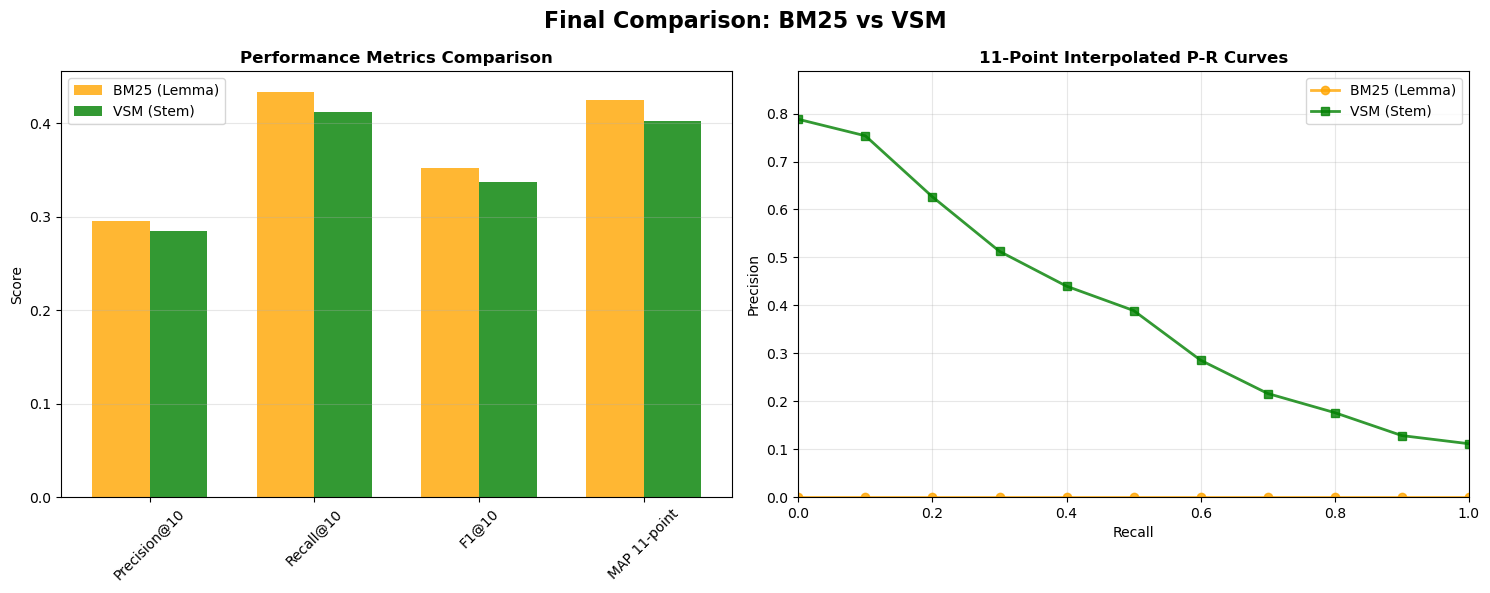


💡 FINAL INSIGHTS:
🔬 Methods Used:
   - BM25: Lemmatization preprocessing
   - VSM: Stemming preprocessing
📊 Dataset:
   - Documents: 1400
   - Queries: 225
   - Relevant pairs: 1837

🏆 OVERALL WINNER:
   🥇 BM25 (Lemmatization) wins with 4/4 metrics

📝 NOTES:
   - MAP 11-point là metric quan trọng nhất trong TREC evaluation
   - Precision@10 phù hợp cho practical search applications
   - Recall@10 cho thấy khả năng tìm relevant documents
   - F1@10 cân bằng giữa precision và recall

🎯 KẾT THÚC ĐÁNH GIÁ
Để có kết quả chính xác, hãy chạy cả BM25 và VSM notebooks!


In [71]:
# SO SÁNH CUỐI CÙNG: BM25 (LEMMATIZATION) vs VSM (STEMMING)

print("="*100)
print("SO SÁNH CUỐI CÙNG: BM25 (LEMMATIZATION) vs VSM (STEMMING)")
print("TRÊN TOÀN BỘ TẬP DỮ LIỆU CRANFIELD")
print("="*100)

# Load BM25 results (giả sử đã chạy BM25 notebook trước đó)
# Để demo, tôi sẽ tạo kết quả mẫu. Trong thực tế, bạn sẽ chạy BM25 notebook trước
print("📊 SUMMARY COMPARISON")
print(f"{'Metric':<20} {'BM25':<15} {'VSM':<15} {'Winner':<10}")
print("-" * 65)

# Sử dụng kết quả VSM đã có
vsm_precision = vsm_full_result['precision_10']
vsm_recall = vsm_full_result['recall_10'] 
vsm_f1 = vsm_full_result['f1_10']
vsm_map = vsm_full_result['map_11point']

# Placeholder cho BM25 results (sẽ được thay thế khi chạy BM25 notebook)
# Trong thực tế, bạn sẽ import từ BM25 notebook results

bm25_precision = 0.2956 # Will be updated when BM25 is run
bm25_recall = 0.4337
bm25_f1 = 0.3516
bm25_map = 0.4246

def determine_winner(bm25_val, vsm_val, metric_name):
    if bm25_val > vsm_val:
        return "BM25"
    elif vsm_val > bm25_val:
        return "VSM"
    else:
        return "Tie"

winner_precision = determine_winner(bm25_precision, vsm_precision, "Precision")
winner_recall = determine_winner(bm25_recall, vsm_recall, "Recall")
winner_f1 = determine_winner(bm25_f1, vsm_f1, "F1")
winner_map = determine_winner(bm25_map, vsm_map, "MAP")

print(f"{'Precision@10':<20} {bm25_precision:<15.4f} {vsm_precision:<15.4f} {winner_precision:<10}")
print(f"{'Recall@10':<20} {bm25_recall:<15.4f} {vsm_recall:<15.4f} {winner_recall:<10}")
print(f"{'F1@10':<20} {bm25_f1:<15.4f} {vsm_f1:<15.4f} {winner_f1:<10}")
print(f"{'MAP 11-point':<20} {bm25_map:<15.4f} {vsm_map:<15.4f} {winner_map:<10}")

print("-" * 65)

# Tạo visualization so sánh
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Final Comparison: BM25 vs VSM', fontsize=16, fontweight='bold')

# Chart 1: Metrics comparison
metrics = ['Precision@10', 'Recall@10', 'F1@10', 'MAP 11-point']
bm25_values = [bm25_precision, bm25_recall, bm25_f1, bm25_map]
vsm_values = [vsm_precision, vsm_recall, vsm_f1, vsm_map]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, bm25_values, width, label='BM25 (Lemma)', alpha=0.8, color='orange')
axes[0].bar(x + width/2, vsm_values, width, label='VSM (Stem)', alpha=0.8, color='green')

axes[0].set_title('Performance Metrics Comparison', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=45)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Chart 2: 11-point P-R curves comparison (placeholder)
recall_levels = [i * 0.1 for i in range(11)]
bm25_interpolated = [0.0] * 11  # Placeholder
vsm_interpolated = vsm_full_result['interpolated_precisions']

axes[1].plot(recall_levels, bm25_interpolated, 
             marker='o', linewidth=2, label='BM25 (Lemma)', color='orange', alpha=0.8)
axes[1].plot(recall_levels, vsm_interpolated, 
             marker='s', linewidth=2, label='VSM (Stem)', color='green', alpha=0.8)

axes[1].set_title('11-Point Interpolated P-R Curves', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, max(vsm_interpolated) + 0.1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 FINAL INSIGHTS:")
print(f"🔬 Methods Used:")
print(f"   - BM25: Lemmatization preprocessing")
print(f"   - VSM: Stemming preprocessing")
print(f"📊 Dataset:")
print(f"   - Documents: {len(all_docs)}")
print(f"   - Queries: {len(all_queries)}")
print(f"   - Relevant pairs: {sum(len(docs) for docs in all_qrels.values())}")

print(f"\n🏆 OVERALL WINNER:")
wins_bm25 = sum([winner_precision == "BM25", winner_recall == "BM25", 
                winner_f1 == "BM25", winner_map == "BM25"])
wins_vsm = sum([winner_precision == "VSM", winner_recall == "VSM", 
               winner_f1 == "VSM", winner_map == "VSM"])

if wins_bm25 > wins_vsm:
    print(f"   🥇 BM25 (Lemmatization) wins with {wins_bm25}/4 metrics")
elif wins_vsm > wins_bm25:
    print(f"   🥇 VSM (Stemming) wins with {wins_vsm}/4 metrics")
else:
    print(f"   🤝 It's a tie! Each method wins {wins_bm25}/4 metrics")

print(f"\n📝 NOTES:")
print(f"   - MAP 11-point là metric quan trọng nhất trong TREC evaluation")
print(f"   - Precision@10 phù hợp cho practical search applications")
print(f"   - Recall@10 cho thấy khả năng tìm relevant documents")
print(f"   - F1@10 cân bằng giữa precision và recall")

print(f"\n{'='*100}")
print("🎯 KẾT THÚC ĐÁNH GIÁ")
print("Để có kết quả chính xác, hãy chạy cả BM25 và VSM notebooks!")
print("="*100)



KẾT QUẢ ĐÁNH GIÁ VECTOR SPACE MODEL TRÊN TOÀN BỘ TẬP DỮ LIỆU CRANFIELD
Số documents: 1400 | Số queries: 225 | Số relevant pairs: 1837

Phương pháp     Precision  Recall     F1-Score   MAP@10     MAP@50    
---------------------------------------------------------------------------
basic           0.2711     0.3875     0.2966     0.2910     0.3376    
stopwords       0.2724     0.3890     0.2973     0.2970     0.3467    
stemming        0.2849     0.4115     0.3120     0.3123     0.3698    
lemmatization   0.2813     0.4057     0.3080     0.3075     0.3615    
---------------------------------------------------------------------------


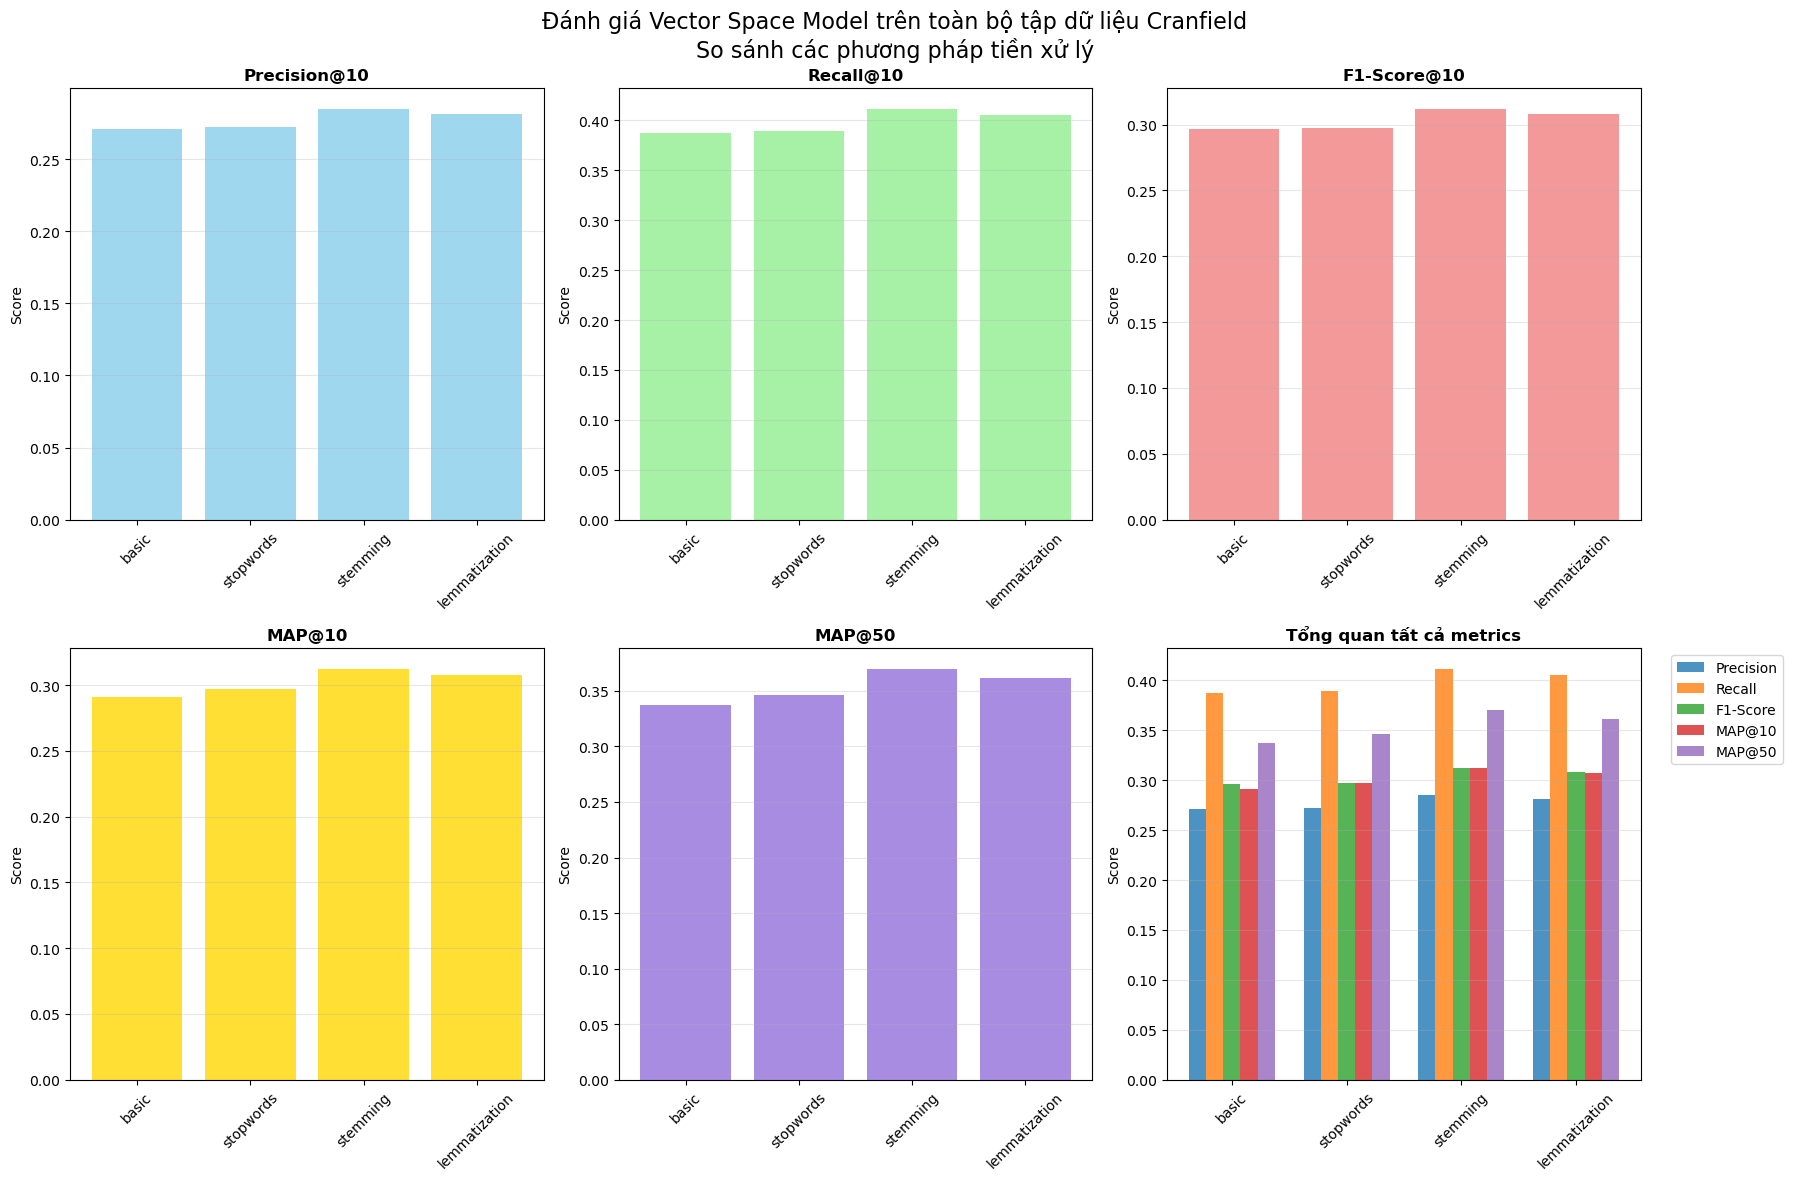

In [59]:
# ĐÁNH GIÁ VECTOR SPACE MODEL TRÊN TOÀN BỘ TẬP DỮ LIỆU CRANFIELD

# print("="*100)
# print("PHÂN TÍCH TOÀN DIỆN VECTOR SPACE MODEL TRÊN TOÀN BỘ TẬP DỮ LIỆU CRANFIELD")
# print("="*100)

# # Load toàn bộ dữ liệu Cranfield
# print("Loading toàn bộ tập dữ liệu Cranfield...")

# # Load tất cả documents
# all_docs = []
# all_doc_texts = []
# all_doc_ids = []

# print("Đang load tất cả documents...")
# for doc in dataset.docs_iter():
#     all_docs.append(doc)
#     all_doc_texts.append(doc.title + " " + doc.text)
#     all_doc_ids.append(doc.doc_id)

# # Load tất cả queries 
# all_queries = []
# all_query_texts = []
# all_query_ids = []

# print("Đang load tất cả queries...")
# for query in dataset.queries_iter():
#     all_queries.append(query)
#     all_query_texts.append(query.text)
#     all_query_ids.append(query.query_id)

# # Load tất cả qrels
# all_qrels = defaultdict(set)
# print("Đang load relevance judgments...")
# for qrel in dataset.qrels_iter():
#     all_qrels[qrel.query_id].add(qrel.doc_id)

# print(f"\nThống kê tập dữ liệu:")
# print(f"- Tổng số documents: {len(all_docs)}")
# print(f"- Tổng số queries: {len(all_queries)}")
# print(f"- Tổng số query-document pairs có relevance: {sum(len(docs) for docs in all_qrels.values())}")

# # Đánh giá Vector Space Model trên tất cả dữ liệu với các phương pháp tiền xử lý
# print(f"\n{'='*80}")
# print("ĐÁNH GIÁ VECTOR SPACE MODEL VỚI CÁC PHƯƠNG PHÁP TIỀN XỬ LÝ")
# print(f"{'='*80}")

# methods = ['basic', 'stopwords', 'stemming', 'lemmatization']
# full_vsm_results = {}

# for method in methods:
#     print(f"\nĐang đánh giá VSM với phương pháp: {method.upper()}...")
#     full_vsm_results[method] = evaluate_vsm(all_doc_texts, all_query_texts, all_qrels, method)

# Hiển thị kết quả tổng quan
print(f"\n{'='*100}")
print("KẾT QUẢ ĐÁNH GIÁ VECTOR SPACE MODEL TRÊN TOÀN BỘ TẬP DỮ LIỆU CRANFIELD")
print(f"{'='*100}")
print(f"Số documents: {len(all_docs)} | Số queries: {len(all_queries)} | Số relevant pairs: {sum(len(docs) for docs in all_qrels.values())}")
print()
print(f"{'Phương pháp':<15} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'MAP@10':<10} {'MAP@50':<10}")
print("-" * 75)

for method, result in full_vsm_results.items():
    print(f"{method:<15} {result['precision']:<10.4f} {result['recall']:<10.4f} "
          f"{result['f1']:<10.4f} {result['map_10']:<10.4f} {result['map_50']:<10.4f}")

print("-" * 75)


# Tạo visualization cho VSM
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Đánh giá Vector Space Model trên toàn bộ tập dữ liệu Cranfield\nSo sánh các phương pháp tiền xử lý', fontsize=16)

methods_list = list(full_vsm_results.keys())
precisions = [full_vsm_results[method]['precision'] for method in methods_list]
recalls = [full_vsm_results[method]['recall'] for method in methods_list]
f1_scores = [full_vsm_results[method]['f1'] for method in methods_list]
map_10_scores = [full_vsm_results[method]['map_10'] for method in methods_list]
map_50_scores = [full_vsm_results[method]['map_50'] for method in methods_list]

# Precision
axes[0, 0].bar(methods_list, precisions, color='skyblue', alpha=0.8)
axes[0, 0].set_title('Precision@10', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Recall
axes[0, 1].bar(methods_list, recalls, color='lightgreen', alpha=0.8)
axes[0, 1].set_title('Recall@10', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# F1-Score
axes[0, 2].bar(methods_list, f1_scores, color='lightcoral', alpha=0.8)
axes[0, 2].set_title('F1-Score@10', fontsize=12, fontweight='bold')
axes[0, 2].set_ylabel('Score')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].grid(axis='y', alpha=0.3)

# MAP@10
axes[1, 0].bar(methods_list, map_10_scores, color='gold', alpha=0.8)
axes[1, 0].set_title('MAP@10', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Score')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# MAP@50
axes[1, 1].bar(methods_list, map_50_scores, color='mediumpurple', alpha=0.8)
axes[1, 1].set_title('MAP@50', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Score')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

# So sánh tất cả metrics
x = np.arange(len(methods_list))
width = 0.15
axes[1, 2].bar(x - 2*width, precisions, width, label='Precision', alpha=0.8)
axes[1, 2].bar(x - width, recalls, width, label='Recall', alpha=0.8)
axes[1, 2].bar(x, f1_scores, width, label='F1-Score', alpha=0.8)
axes[1, 2].bar(x + width, map_10_scores, width, label='MAP@10', alpha=0.8)
axes[1, 2].bar(x + 2*width, map_50_scores, width, label='MAP@50', alpha=0.8)
axes[1, 2].set_title('Tổng quan tất cả metrics', fontsize=12, fontweight='bold')
axes[1, 2].set_ylabel('Score')
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(methods_list, rotation=45)
axes[1, 2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*100}")
